# Implementing Transformer Architecture: A Step-by-Step Guide


- Key sections:
  - 3.1: Encoder and Decoder Stacks
  - 3.2: Attention Mechanism
  - 3.3: Position-wise Feed-Forward Networks
  - 3.4: Embeddings and Softmax
  - 3.5: Positional Encoding
  - 5.4: Regularization (dropout strategy)

## Implementation Strategy
Breaking down the architecture into manageable pieces and gradually adding complexity:

1. Start with foundational components:
   - Embedding + Positional Encoding
   - Single-head self-attention

2. Build up attention mechanism:
   - Extend to multi-head attention
   - Add cross-attention capability
   - Implement attention masking

3. Construct larger components:
   - Encoder (self-attention + FFN)
   - Decoder (masked self-attention + cross-attention + FFN)

4. Combine into final architecture:
   - Encoder-Decoder stack
   - Full Transformer with input/output layers

## Development Tips
1. Visualization and Planning:
   - Draw out tensor dimensions on paper
   - Sketch attention patterns and masks
   - Map each component back to paper equations
   - This helps catch dimension mismatches early!

2. Dimension Cheat Sheet:
   - Input tokens: [batch_size, seq_len]
   - Embeddings: [batch_size, seq_len, d_model]
   - Attention matrices: [batch_size, num_heads, seq_len, seq_len]
   - FFN hidden layer: [batch_size, seq_len, d_ff]
   - Output logits: [batch_size, seq_len, vocab_size]

3. Common Pitfalls:
   - Forgetting to scale dot products by √d_k
   - Applying mask too early or too late
   - Incorrect mask dimensions or application
   - Missing residual connections
   - Wrong order of layer norm and dropout
   - Tensor dimension mismatches in attention
   - Not handling padding properly

4. Performance Considerations:
   - Memory usage scales with sequence length squared
   - Attention computation is O(n²) with sequence length
   - Balance between d_model and num_heads
   - Trade-off between model size and batch size

## Testing Strategy
- Test each component independently
- Verify shape preservation
- Check attention patterns
- Confirm mask effectiveness
- Validate gradient flow
- Monitor numerical stability

Remember: The key to successfully implementing the Transformer is understanding how each piece fits together and maintaining clear dimension tracking throughout the implementation.

In [1]:
from functools import wraps
from typing import Any, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch import functional as F
from torch import nn

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

In [3]:
# device = ["cuda","mps","cpu"]

In [51]:
# a utility for calculating running average
class AverageMeter:
    def __init__(self):
        self.num = 0
        self.tot = 0

    def update(self, val: float, sz: float):
        self.num += val * sz
        self.tot += sz

    def calculate(self) -> float:
        return self.num / self.tot


def averager(func):
    num = 0
    total = 0
    # val = 0.0

    @wraps(func)
    def inner(val, sz):
        nonlocal num
        nonlocal total
        num += val * sz
        total += sz
        print(num, total, num / total)
        return num, total, num / total

    return inner

In [52]:
@averager
def calc_product(n, a):
    return n, a


print(calc_product(2, 3))

6 3 2.0
(6, 3, 2.0)


# Problem 2: Implement a Transformer

## Part 2.A

## Attention Head

In [4]:
import copy
import math

torch.manual_seed(42)


class AttentionHead(nn.Module):
    def __init__(self, dim: int, n_hidden: int):
        # dim: the dimension of the input
        # n_hidden: the dimension of the keys, queries, and values

        super().__init__()

        self.W_K = nn.Linear(dim, n_hidden)  # W_K weight matrix
        self.W_Q = nn.Linear(dim, n_hidden)  # W_Q weight matrix
        self.W_V = nn.Linear(dim, n_hidden)  # W_V weight matrix
        self.n_hidden = n_hidden
        self.dim = dim
        # self.temp = torch.tensor([])
        # self.temp2 = torch.tensor([])
        # self.temp3 = torch.tensor([])

        print(self.count_params())
        # self.calculate_shapes()

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

    # def calculate_shapes(self):
    #     print("Attention Matrix shape",self.temp.shape)
    #     print(f"Before Normalizing Attention Head: {self.temp2.shape}")
    #     print(f"Attention Head final shape: {self.temp3.shape}")

    def calc_attention_mask(
        self, inp: torch.Tensor, mask: Optional[torch.Tensor] = None
    ):
        """
        returns fills inp with -infinity where attention mask is 0..
        so that after softmax output is zero
        """
        if not mask:
            return inp

        return inp.masked_fill(mask == 0, -float("inf"))

    # def forward(
    #     self, x: torch.Tensor, attn_mask: Optional[torch.Tensor]=None
    # ) -> Tuple[torch.Tensor, torch.Tensor]:
    #     """
    #     # x                the inputs. shape: (B x T x dim)
    #     # attn_mask        an attention mask. If None, ignore. If not None, then mask[b, i, j]
    #     #                  contains 1 if (in batch b) token i should attend on token j and 0
    #     #                  otherwise. shape: (B x T x T)
    #     #
    #     # Outputs:
    #     # attn_output      the output of performing self-attention on x. shape: (Batch x Num_tokens x n_hidden)
    #     # alpha            the attention weights (after softmax). shape: (B x T x T)
    #     #
    #     """
    #     print(f"Attention Mask:{attn_mask}")
    #
    #     A, Z = None, None
    #     """
    #     #todo : Compute self attention on x.
    #     #       (1) First project x to the query Q, key K, value V.
    #     #       (2) Then compute the attention weights alpha as:
    #     #                  alpha = softmax(QK^T/sqrt(n_hidden))
    #     #           Make sure to take into account attn_mask such that token i does not attend on token
    #     #           j if attn_mask[b, i, j] == 0. (Hint, in such a case, what value should you set the weight
    #     #           to before the softmax so that after the softmax the value is 0?)
    #     #       (3) The output is a linear combination of the values (weighted by the alphas):
    #     #                  out = alpha V
    #     #       (4) return the output and the alpha after the softmax
    #
    #     # ======= Answer START ========
    #     """
    #     print(f"x={type(x)},{x.shape if type(x) is torch.tensor else len(x)} in attention head")
    #     Q = self.W_Q(x).T
    #     K = self.W_K(x).T
    #     V = self.W_V(x).T
    #     print(f"Without Transpose:{self.W_Q(x).shape}")
    #     print(f"{Q.shape=},{K.shape=},{V.shape=}")
    #     #print(f"{(Q@K.T).shape=}\n\n\n-------------")
    #     #print(f"{torch.matmul(Q,K.T).shape}")
    #     A = torch.matmul(Q,K.transpose(dim0=1,dim1=2))
    #     print(f"{A.shape=}")
    #     self.temp = A
    #     #print(A.shape) # dim*dim
    #     #todo -> causal masking auto regressive.. for time based
    #     # if not attn_mask:
    #     #     out = alpha
    #     # else:
    #     #     first = attn_mask[0,:,1]
    #     #     second = attn_mask[0,:,2]
    #     #     for i in first:
    #     #         for j in second:
    #     #             if j==0:
    #     #                 out=-alpha
    #
    #     #mask = self.calc_attention_mask(A,attn_mask)
    #     #print(self.calculate_shapes())
    #     if attn_mask is not None:
    #         Z=A+attn_mask
    #     else:
    #         Z=A
    #     self.temp2 = Z
    #     #print(f"Masking score: {inp.shape}")
    #
    #     Z = torch.softmax(Z/n_hidden**.5,dim=-1)
    #     print(f"before multiplication{Z.shape=}")
    #     Z = torch.matmul(Z,V)
    #     #print(f"Checking shape along dim 1: {torch.softmax(Z,dim=1).shape}")
    #     print(f"{Z.shape=}")
    #
    #     self.temp3 = Z
    #     #self.calculate_shapes()
    #
    #
    #
    #
    #
    #
    #     #attn_output = torch.softmax(attn_scores,dim=-1)
    #
    #     # ======= Answer  END ========
    #     print("Attention Head Successful!")
    #     print(f"Attention output shape={A.shape}, Z={Z.shape} calculated for attention head\n\n------------")
    #
    #     return A,Z

    def forward(
        self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # x shape: (B, T, dim)
        print("\n\n-----------------------\nIn Attention Head:\n\n=")
        print(f"{x.shape=}")
        # 1. Project inputs to Q, K, V (Keep 3D structure intact)
        Q = self.W_Q(x)  # (B, T, n_hidden)
        K = self.W_K(x)  # (B, T, n_hidden)
        V = self.W_V(x)  # (B, T, n_hidden)
        print(f"{Q.shape=},{K.shape=},{V.shape=}")
        # 2. Compute attention scores matrix
        # Transpose the last two dimensions of K to match (B, n_hidden, T)
        # A = torch.matmul(Q, K.transpose(-2, -1))  # Shape: (B, T, T)
        # print(f"{A.shape=}")
        # scores = A
        A = Q @ K.transpose(-2, -1)
        # print(f"Second way {A.shape=}")
        # 3. Apply the Attention Mask safely before Softmax

        if attn_mask is not None:
            # Everywhere mask is 0, fill scores with a massive negative number
            A = A.masked_fill(attn_mask == 0, float("-inf"))

        # 4. Normalize and apply Softmax to get Alpha weights
        # doing layer by layer so in each layer n_hidden dimensions
        A = torch.softmax(A / math.sqrt(self.n_hidden), dim=-1)  # Shape: (B, T, T)

        # 5. Compute the final context vector
        # (B, T, T) x (B, T, n_hidden) -> (B, T, n_hidden)
        Z = A @ V

        # 6. Return strictly in the order requested by your docstring/parent class
        return Z, A

    # def backward(self):

### Debug

In [5]:
import torch
import torch.nn as nn

# 1. Define the dimensions
BATCH_SIZE = 10
SEQ_LEN = 100
INPUT_DIM = 64
OUTPUT_DIM = 32

# 2. Instantiate the linear layer
# It expects the incoming features to be 64, and transforms them into 32
linear_layer = nn.Sequential(
    nn.Linear(in_features=INPUT_DIM, out_features=1),
    nn.Linear(in_features=1, out_features=OUTPUT_DIM),
)

# 3. Create a 3D input tensor matching your Transformer data layout
# Shape: (Batch Size, Sequence Length, Features)
x = torch.randn(BATCH_SIZE, SEQ_LEN, INPUT_DIM)
print(f"Input shape:  {x.shape}")  # Output: torch.Size([10, 100, 64])

# 4. Pass the tensor through the layer
output = linear_layer(x)
print(f"Output shape: {output.shape}")  # Output: torch.Size([10, 100, 32])

Input shape:  torch.Size([10, 100, 64])
Output shape: torch.Size([10, 100, 32])


In [24]:
x.transpose(-2, -1).shape

torch.Size([10, 64, 100])

In [25]:
attention = AttentionHead(INPUT_DIM, OUTPUT_DIM)
attention.count_params()
Z, A = attention(x)

6240


-----------------------
In Attention Head:

=
x.shape=torch.Size([10, 100, 64])
Q.shape=torch.Size([10, 100, 32]),K.shape=torch.Size([10, 100, 32]),V.shape=torch.Size([10, 100, 32])


In [26]:
Z.shape

torch.Size([10, 100, 32])

In [27]:
A.shape

torch.Size([10, 100, 100])

In [28]:
x = torch.tensor([[2.0, 3]] * 3)
x

tensor([[2., 3.],
        [2., 3.],
        [2., 3.]])

In [29]:
inp = torch.randn(10, 100, 64)

In [30]:
attention_mask = torch.tensor([[0, 1.0], [1.0, 0]])

In [31]:
x.shape

torch.Size([3, 2])

In [32]:
# import copy
# attention_mask = copy.deepcopy(x)

In [33]:
# model(inp,attn_mask=None)

In [34]:
torch.tensor([[2.0, 3]] * 3) + torch.tensor([[2, 3]])

tensor([[4., 6.],
        [4., 6.],
        [4., 6.]])

In [35]:
# class LinearModules(nn.Module):
#     def __init__(self, dim,hidden,heads):
#         super().__init__()
#         self.linear_list = nn.ModuleList([
#            AttentionHead(dim,hidden) for _ in range(heads)
#         ])
#         #print(self.linear_list[0].count_params())
#
#     def forward(self,x,attn_mask=None):
#         print(f"x={x}length={len(x)} in Multi Attention Head\n\n------------")
#         for index,layer in enumerate(self.linear_list):
#             x=self.linear_list[index](x)
#             W0 = layer(x)
#             #print(f"W0={W0}")
#
#             #x=list(x)
#             print(f"x={x}len={len(x)},{type(x)}")
#
#         print(f"x={x}len={len(x)} in Multi Attention Head after")
#         print(f"Concated Heads: {torch.concat(x)}")
#         return torch.concat(x)@W0
#         #return x

In [36]:
# model = LinearModules(2,3,1)
# model

In [37]:
# for p in model.parameters():
#     print(p.shape)

In [38]:
for i, p in model.named_modules():
    print(i, p)

 Linear(in_features=32, out_features=1, bias=False)


In [39]:
m = AttentionHead(2, 3)
m.train()
pred = m(torch.tensor([[2.0, 2]] * 3))

27


-----------------------
In Attention Head:

=
x.shape=torch.Size([3, 2])
Q.shape=torch.Size([3, 3]),K.shape=torch.Size([3, 3]),V.shape=torch.Size([3, 3])


In [40]:
x, y = pred
x

tensor([[ 0.0232, -2.5779,  1.0080],
        [ 0.0232, -2.5779,  1.0080],
        [ 0.0232, -2.5779,  1.0080]], grad_fn=<MmBackward0>)

In [41]:
print(y)

tensor([[0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333]], grad_fn=<SoftmaxBackward0>)


In [42]:
# model.train()
# pred = model(torch.tensor([[2.0,2]]*3))
# pred

In [43]:
# list(model.get_submodule("linear_list.0").parameters())

## Part 2.B Multi Attention Head


This line creates a standard linear layer (W_o) that merges the independent representations learned by your individual attention heads back into a single unified vector space.
Here is exactly why it is configured with those dimensions:


#### 1. Fixing the Dimension Explosion


Each individual AttentionHead outputs a tensor of shape (B, T, n_hidden).
When you loop through all your heads and concatenate (torch.cat) them along the final axis, their dimensions combine like this:
$$\text{Shape: } (B, T, \color{lightgreen}{n\_hidden}) \times \text{num\_heads} \xrightarrow{\text{torch.cat}} (B, T, \color{lightblue}{num\_heads \times n\_hidden})$$
If you did not use this projection layer, the data moving to the next block in your neural network would be far too wide (num_heads * n_hidden) instead of the standard model dimension (dim).


#### 2. Allowing Heads to Communicate

Concatenation simply glues the heads next to each other, meaning the features found by Head #1 do not interact with Head #2. Passing the concatenated tensor through nn.Linear performs a matrix multiplication that mathematically mixes all the heads' outputs together.


#### 3. Re-aligning with Residual Connections


In transformer architectures, you usually add the original input $x$ back to the attention output (a residual connection):
$$\text{Output} = x + \text{Attention}(x)$$
For this addition ($+$) to work, the final output must have the exact same shape as the input tensor $x$, which is (B, T, dim). The out_proj layer guarantees this shape matches perfectly.



In [6]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        # dim: the dimension of the input
        # n_hidden: the hidden dimensions for the attention layer
        # num_heads: the number of attention heads
        super().__init__()
        self.H = num_heads
        # TODO: set up your parameters for multi-head attention. You should initialize
        #       num_heads attention heads (see nn.ModuleList) as well as a linear layer
        #       that projects the concatenated outputs of each head into dim
        #       (what size should this linear layer be?)

        # ======= Answer START ========
        # self.attention = AttentionHead(dim=dim,n_hidden=n_hidden)
        self.linear_list = nn.ModuleList(
            [AttentionHead(dim, n_hidden) for _ in range(num_heads)]
        )
        self.dim = dim

        # 2. Final linear projection layer
        # Maps concatenated outputs (num_heads * n_hidden) back to original dim
        self.W0 = nn.Linear(n_hidden * num_heads, dim)

        # ======= Answer  END ========

    # todo in parallel
    # def forward(
    #     self, x: torch.Tensor, attn_mask: Optional[torch.Tensor]
    # ) -> Tuple[torch.Tensor, torch.Tensor]:
    #     # x                the inputs. shape: (B x T x dim)
    #     # attn_mask        an attention mask. If None, ignore. If not None, then mask[b, i, j]
    #     #                  contains 1 if (in batch b) token i should attend on token j and 0
    #     #                  otherwise. shape: (B x T x T)
    #     #
    #     # Outputs:
    #     # attn_output      the output of performing multi-headed self-attention on x.
    #     #                  shape: (B x T x dim)
    #     # attn_alphas      the attention weights of each of the attention heads.
    #     #                  shape: (B x Num_heads x T x T)
    #
    #     A,Z,W0 = None, None,None
    #
    #     # TODO: Compute multi-headed attention. Loop through each of your attention heads
    #     #       and collect the outputs. Concatenate them together along the hidden dimension,
    #     #       and then project them back into the output dimension (dim). Return both
    #     #       the final attention outputs as well as the alphas from each head.
    #
    #     # ======= Answer START ========
    #     print(f"x={x}length={len(x)},type={type(x)} in Multi Attention Head\n\n------------")

    def forward(
        self, x: torch.Tensor, attn_mask: Optional[torch.Tensor]
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        Z_concat = []
        A_concat = []
        head_outputs = []
        head_alphas = []
        print(f"\n\n In Multi headed Attention: {x.shape=}")
        for head in self.linear_list:
            #     Z,A = head(x,attn_mask=attn_mask)
            #     Z_concat.append(Z)
            #     A_concat.append(A)
            # # 4. Concatenate outputs from all heads along the last (hidden) dimension
            # # Resulting shape: (B, T, num_heads * n_hidden)
            # A=torch.cat(A_concat,dim=-1)
            # Z=self.W0(A)
            # Ah=torch.stack(Z_concat,dim=1)
            # return Z,Ah
            out, alpha = head(x, attn_mask=attn_mask)
            print(f"Multi Headed Attention: {out.shape=},{alpha.shape=}")
            print(f"{head=} {out=}")
            head_outputs.append(out)  # Each item shape: (B, T, n_hidden)
            head_alphas.append(alpha)  # Each item shape: (B, T, T)

        # 4. Concatenate outputs from all heads along the last (hidden) dimension
        # Resulting shape: (B, T, num_heads * n_hidden)
        # print(f"{len(head_alphas[0])},{len(head_outputs[0])}")
        concatenated_heads = torch.cat(head_outputs, dim=-1)

        # concatenated_heads=concatenated_heads.transpose(0,1)

        # 5. Project the concatenated representation back to 'dim'
        # Resulting shape: (B, T, dim)
        # print(f"Multi Headed Attention: {concatenated_heads.shape=}")
        attn_output = self.W0(concatenated_heads)
        # print(
        #     f"Multi Headed Attention: {attn_output.shape=} With output head successful\n\n-----------"
        # )

        # 6. Stack attention weights from all heads along a new head dimension
        # Resulting shape: (B, num_heads, T, T)

        attn_alphas = torch.stack(head_alphas, dim=1)
        print(f"{attn_alphas.shape=}")
        print("Multi Headed Attention Successful\n\n\n--------------------------")
        return attn_output, attn_alphas

## Multi Head Attention Parallel

In [45]:
# todo
class MultiHeadedAttentionParallel(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        self.Wq = nn.Linear(dim, n_hidden)
        self.Wk = nn.Linear(dim, n_hidden)
        self.Wv = nn.Linear(dim, n_hidden)

        self.H = num_heads
        self.d_h = int(dim / num_heads)
        self.W0 = nn.Linear(n_hidden * num_heads, self.d_h)
        self.layer_size = n_hidden

    def count_params(self):
        return sum(p.view(-1).shape[0] for p in self.parameters())

    def multi_head_qkv(self, x, head):
        Qh = self.Wq(x)
        Kh = self.Wk(x)
        Vh = self.Wv(x)

    def forward(self, x, attn_mask=None):
        Q = self.Wq(x)

In [7]:
from typing import Optional, Tuple

import torch
import torch.nn as nn


class MultiHeadedAttention(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.n_hidden = n_hidden

        # 1. One combined projection layer for all heads at once
        # This replaces your nn.ModuleList loop completely
        self.qkv_projection = nn.Linear(dim, num_heads * n_hidden * 3, bias=False)

        # 2. Final output projection (W0)
        self.W0 = nn.Linear(num_heads * n_hidden, dim)

    def forward(
        self, x: torch.Tensor, attn_mask=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        B, T, dim = x.shape  # Batch Size, Token Size, model_dim?

        # 3. Project all inputs for all heads in parallel
        # Shape becomes: (B, T, num_heads * n_hidden * 3)
        qkv = self.qkv_projection(x)

        # 4. Reshape and split into separate Query, Key, and Value tensors
        # New shape format: (B, num_heads, T, n_hidden)
        qkv = qkv.reshape(B, T, self.num_heads, 3 * self.n_hidden).transpose(1, 2)
        q, k, v = qkv.chunk(3, dim=-1)

        # 5. Compute parallel attention weights (Alphas)
        # Shape: (B, num_heads, T, T)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.n_hidden**0.5)

        if attn_mask is not None:
            # Mask format: Convert 0s to a very large negative value (-1e9)
            # Unsqueeze mask to match (B, 1, T, T) for broadcasting across heads
            scores = scores.masked_fill(attn_mask.unsqueeze(1) == 0, float("-inf"))

        attn_alphas = torch.softmax(scores, dim=-1)

        # 6. Apply weights to values
        # Shape: (B, num_heads, T, n_hidden)
        context = attn_alphas @ v

        # 7. Concatenate all heads back together efficiently
        # Permute back to (B, T, num_heads, n_hidden) -> Flatten to (B, T, num_heads * n_hidden)
        A = context.transpose(1, 2).reshape(B, T, self.num_heads * self.n_hidden)

        # 8. Run through final output projection W0
        Z = self.W0(A)

        return Z, attn_alphas

### With dropout

In [ ]:
class AttentionHead(nn.Module):
    """
    Multi Attention Head
    Splits Input in Q,K,V

    """

    def __init__(self, model_dim, H, dropout_rate=0.1):
        super().__init__()
        self.Wq = nn.Linear(model_dim, model_dim)
        self.Wk = nn.Linear(model_dim, model_dim)
        self.Wv = nn.Linear(model_dim, model_dim)
        self.H = H
        self.d_h = int(model_dim / H)
        self.dropout = nn.Dropout(p=dropout_rate)

        self.Wo = nn.Linear(model_dim, model_dim)

    def forward(self, sequences, attn_mask=False):
        """Input shape: [batch_size, seq_len, d_model=num_head * d_head]
        # if key_value_states are provided this layer is used as a cross-attention layer for text translation..

        # for the decoder

        """
        batch_size, seq_len, model_dim = sequences.size()
        Q = self.Wq(sequences)

        K, V = self.Wk(sequences), self.Wv(sequences)

        A = Q @ K.transpose(-2, -1)
        if attn_mask is not None and attn_mask:
            A = A.masked_fill(attn_mask == 0, -float("inf"))
        A = F.softmax(A / self.d_h**0.5, dim=-1)  # Applying softmax
        A = self.dropout(A)  # Final

        # Output Z

        Z = A @ V  # torch,tensor
        print(f"{Z.shape=}")
        ### Concatenating in parallel along heads and sequences
        ## Because continuous input
        # Z = (Z.contiguous().view(
        #     batch_size,seq_len,self.H*self.d_h)
        # )
        # 2. Transpose to move seq_len before H: shape (batch_size, seq_len, H, d_h)
        # NOTE: Z is now NON-CONTIGUOUS in memory!
        Z = Z.transpose(1, 2).reshape(batch_size, seq_len, model_dim)
        # 3. Concatenate all heads into d_model = H * d_h
        # Fails without .contiguous():
        # Z = Z.contiguous().view(batch_size,seq_len,self.H*self.d_h)
        # final linear projections
        Z = self.Wo(Z)
        return A, Z

In [22]:
a = torch.tensor([[1, 2], [2, 3]])
a

tensor([[1, 2],
        [2, 3]])

In [25]:
from IPython.display import display

a.unsqueeze(dim=0).shape

torch.Size([1, 2, 2])

In [26]:
a.unsqueeze(dim=1).shape

torch.Size([2, 1, 2])

In [167]:
class MultiAttentionHead(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        # dim: the dimension of the input
        # n_hidden: the hidden dimensions for the attention layer
        # num_heads: the number of attention heads
        super().__init__()
        self.H = num_heads
        self.n_hidden = n_hidden
        # TODO: set up your parameters for multi-head attention. You should initialize
        #       num_heads attention heads (see nn.ModuleList) as well as a linear layer
        #       that projects the concatenated outputs of each head into dim
        #       (what size should this linear layer be?)

        # self.Wq = nn.Linear(dim,n_hidden)
        # self.Wk = nn.Linear(dim,n_hidden)
        # self.Wv = nn.Linear(dim,n_hidden)

        self.qkv = nn.Linear(
            dim, num_heads * n_hidden * 3, bias=False
        )  # Why bias false?

        self.WO = nn.Linear(num_heads * n_hidden, dim)

    def forward(
        self, x: torch.Tensor, attn_mask=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
                attention mask
                masks future inputs

        that those blank tokens get filled in with the prediction

        """
        batch_size, token_size, dim = x.shape
        QKV = self.qkv(x)
        print(f"{QKV.shape=}")
        QKV = QKV.reshape(batch_size, token_size, self.H * self.n_hidden * 3)
        print(f"After reshaping reshaped: {QKV.shape=}")
        QKV = QKV.transpose(-2, -1)
        Q, K, V = QKV.chunk(3, dim=-1)

        # First rescaling then applying attention mask if given
        A = Q @ K.transpose(-2, -1) / (self.n_hidden**0.5)

        scores = A

        if attn_mask is not None:
            """
            causal masking future inputs of 0 to negative so that softmax will return 0
            """
            scores = scores.masked_fill(attn_mask.unsqueeze(1) == 0, float("-inf"))
        # Normalizing inputs across each layer
        A = torch.softmax(scores, dim=-1)

        # Calculating output for 1 head

        Z = A @ V

        # Concatenating outputs transpose and reshape along heads
        Z = Z.transpose(-2, -1)
        Z = Z.reshape(batch_size, token_size, self.H * self.n_hidden)

        # Final Projection
        Z = self.WO(Z)

        # return output, attention
        return Z, A

torch.Size([10, 100, 32])

In [48]:
print(torch.stack((Z, Z), dim=1).shape)
print(torch.stack((Z, Z), dim=-1).shape)

torch.Size([10, 2, 100, 32])
torch.Size([10, 100, 32, 2])


In [49]:
print(torch.cat([Z, Z], dim=0).shape)

print(torch.cat([Z, Z], dim=-1).shape)
print(torch.cat([Z, Z], dim=1).shape)

torch.Size([20, 100, 32])
torch.Size([10, 100, 64])
torch.Size([10, 200, 32])


In [50]:
print(torch.concat([Z, Z], dim=0).shape)

print(torch.concat([Z, Z], dim=1).shape)
print(torch.concat([Z, Z], dim=-1).shape)

torch.Size([20, 100, 32])
torch.Size([10, 200, 32])
torch.Size([10, 100, 64])


In [15]:
torch.manual_seed(42)
x = torch.randn(10, 3, 3)

In [52]:
multi_attn_head_model = MultiHeadedAttentionParallel(dim=3, n_hidden=9, num_heads=2)

In [53]:
multi_attn_head_model

MultiHeadedAttentionParallel(
  (qkv_projection): Linear(in_features=3, out_features=54, bias=False)
  (W0): Linear(in_features=18, out_features=3, bias=True)
)

In [54]:
list(multi_attn_head_model.named_modules())

[('',
  MultiHeadedAttentionParallel(
    (qkv_projection): Linear(in_features=3, out_features=54, bias=False)
    (W0): Linear(in_features=18, out_features=3, bias=True)
  )),
 ('qkv_projection', Linear(in_features=3, out_features=54, bias=False)),
 ('W0', Linear(in_features=18, out_features=3, bias=True))]

#### Each head will pay attention to its own set of W,K,V

In [55]:
Z1, A = multi_attn_head_model(x)

In [56]:
Z1

tensor([[[ 0.0911,  0.4180,  0.4624],
         [ 0.2137, -0.0696, -0.5680],
         [ 0.0356,  0.3008, -0.3748]],

        [[ 0.2077, -0.2042, -0.1520],
         [ 0.2025, -0.2559, -0.2576],
         [ 0.2011, -0.1693, -0.0122]],

        [[-0.0029,  0.3210, -0.9519],
         [ 0.0745,  0.2551, -0.6207],
         [ 0.0656,  0.2612, -0.6681]],

        [[ 0.0915,  0.3099, -0.2938],
         [ 0.2325, -0.0068, -0.3535],
         [ 0.1213,  0.2620, -0.1419]],

        [[ 0.3243, -0.0525,  0.3276],
         [ 0.3194, -0.0546,  0.3241],
         [ 0.3071, -0.0487,  0.2409]],

        [[ 0.3593, -0.2676, -0.0657],
         [ 0.3155, -0.4896, -0.2399],
         [ 0.2357, -0.1555, -0.0971]],

        [[ 0.1096,  0.3236,  0.0112],
         [ 0.1166,  0.2731,  0.0806],
         [ 0.2025,  0.1679,  0.1349]],

        [[ 0.1801, -0.0430, -0.7174],
         [ 0.1457, -0.0614, -0.8503],
         [ 0.0638, -0.0049, -1.0358]],

        [[ 0.1250,  0.0034,  0.1533],
         [ 0.1274,  0.0163,  0.168

In [57]:
A

tensor([[[[0.2179, 0.6126, 0.1696],
          [0.2116, 0.0391, 0.7493],
          [0.4120, 0.3575, 0.2305]],

         [[0.0506, 0.4888, 0.4605],
          [0.7732, 0.0953, 0.1316],
          [0.4916, 0.2782, 0.2302]]],


        [[[0.4050, 0.1880, 0.4070],
          [0.4992, 0.2492, 0.2516],
          [0.3247, 0.4005, 0.2749]],

         [[0.2115, 0.5167, 0.2718],
          [0.3388, 0.2243, 0.4369],
          [0.2773, 0.4971, 0.2255]]],


        [[[0.2895, 0.3711, 0.3394],
          [0.3602, 0.3690, 0.2708],
          [0.3430, 0.3636, 0.2934]],

         [[0.2654, 0.3728, 0.3618],
          [0.5474, 0.2296, 0.2230],
          [0.5148, 0.2646, 0.2206]]],


        [[[0.2227, 0.5399, 0.2375],
          [0.5588, 0.2233, 0.2178],
          [0.1740, 0.1836, 0.6424]],

         [[0.2415, 0.3021, 0.4564],
          [0.3363, 0.2634, 0.4003],
          [0.3892, 0.4229, 0.1880]]],


        [[[0.3277, 0.2836, 0.3888],
          [0.3234, 0.2909, 0.3858],
          [0.3821, 0.2670, 0.3509]],

  

In [58]:
Z1.shape

torch.Size([10, 3, 3])

In [59]:
A.shape

torch.Size([10, 2, 3, 3])

In [60]:
A.requires_grad

True

In [61]:
# multi_attn_head_model(x,attn_mask=None)

## Part 2.C

### Feed Forward Network

In [22]:
class MultiAttentionHead(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        # dim: the dimension of the input
        # n_hidden: the hidden dimensions for the attention layer
        # num_heads: the number of attention heads
        super().__init__()
        self.H = num_heads
        self.n_hidden = n_hidden
        # TODO: set up your parameters for multi-head attention. You should initialize
        #       num_heads attention heads (see nn.ModuleList) as well as a linear layer
        #       that projects the concatenated outputs of each head into dim
        #       (what size should this linear layer be?)

        # self.Wq = nn.Linear(dim,n_hidden)
        # self.Wk = nn.Linear(dim,n_hidden)
        # self.Wv = nn.Linear(dim,n_hidden)

        self.qkv = nn.Linear(
            dim, num_heads * n_hidden * 3, bias=False
        )  # Why bias false?

        self.WO = nn.Linear(num_heads * n_hidden, dim)

    def forward(
        self, x: torch.Tensor, attn_mask=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
                attention mask
                masks future inputs

        that those blank tokens get filled in with the prediction

        """
        batch_size, token_size, dim = x.shape
        QKV = self.qkv(x)
        print(f"{QKV.shape=}")
        QKV = QKV.reshape(batch_size, token_size, self.H * self.n_hidden * 3)
        print(f"After reshaping reshaped: {QKV.shape=}")
        QKV = QKV.transpose(-2, -1)
        Q, K, V = QKV.chunk(3, dim=-1)

        # First rescaling then applying attention mask if given
        A = Q @ K.transpose(-2, -1) / (self.n_hidden**0.5)

        scores = A

        if attn_mask is not None:
            """
            causal masking future inputs of 0 to negative so that softmax will return 0
            """
            scores = scores.masked_fill(attn_mask.unsqueeze(1) == 0, float("-inf"))
        # Normalizing inputs across each layer
        A = torch.softmax(scores, dim=-1)

        # Calculating output for 1 head

        Z = A @ V

        # Concatenating outputs transpose and reshape along heads
        Z = Z.transpose(-2, -1)
        Z = Z.reshape(batch_size, token_size, self.H * self.n_hidden)

        # Final Projection
        Z = self.WO(Z)

        # return output, attention
        return Z, A


from typing import Optional, Tuple

import torch
import torch.nn as nn


class MultiHeadedAttention(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.n_hidden = n_hidden

        # 1. One combined projection layer for all heads at once
        # This replaces your nn.ModuleList loop completely
        self.qkv_projection = nn.Linear(dim, num_heads * n_hidden * 3, bias=False)

        # 2. Final output projection (W0)
        self.W0 = nn.Linear(num_heads * n_hidden, dim)

    def forward(
        self, x: torch.Tensor, attn_mask=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        B, T, dim = x.shape  # Batch Size, Token Size, model_dim?

        # 3. Project all inputs for all heads in parallel
        # Shape becomes: (B, T, num_heads * n_hidden * 3)
        qkv = self.qkv_projection(x)

        # 4. Reshape and split into separate Query, Key, and Value tensors
        # New shape format: (B, num_heads, T, n_hidden)
        qkv = qkv.reshape(B, T, self.num_heads, 3 * self.n_hidden).transpose(1, 2)
        q, k, v = qkv.chunk(3, dim=-1)

        # 5. Compute parallel attention weights (Alphas)
        # Shape: (B, num_heads, T, T)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.n_hidden**0.5)

        if attn_mask is not None:
            # Mask format: Convert 0s to a very large negative value (-1e9)
            # Unsqueeze mask to match (B, 1, T, T) for broadcasting across heads
            scores = scores.masked_fill(attn_mask.unsqueeze(1) == 0, float("-inf"))

        attn_alphas = torch.softmax(scores, dim=-1)

        # 6. Apply weights to values
        # Shape: (B, num_heads, T, n_hidden)
        context = attn_alphas @ v

        # 7. Concatenate all heads back together efficiently
        # Permute back to (B, T, num_heads, n_hidden) -> Flatten to (B, T, num_heads * n_hidden)
        A = context.transpose(1, 2).reshape(B, T, self.num_heads * self.n_hidden)

        # 8. Run through final output projection W0
        Z = self.W0(A)

        return Z, attn_alphas

In [9]:
class FFN(nn.Module):
    def __init__(self, dim: int, n_hidden: int):
        # dim       the dimension of the input
        # n_hidden  the width of the linear layer

        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, n_hidden),
            nn.GELU(),
            nn.Linear(n_hidden, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x         the input. shape: (B x T x dim)

        # Outputs:
        # out       the output of the feed-forward network: (B x T x dim)
        # print("\n\n\nIn FFN-------------------------")
        print(f"{x.shape=}")
        out = self.net(x)
        # print(f"Out={out.shape=}")
        return out

In [10]:
def print_variance(name, data):
    # First dimension(rows) is batch elements
    # Second dimension(columns) is neurons.
    # np_data = data.detach().numpy()

    # Compute variance across neurons and average these variances over members of the batch
    neuron_variance = torch.mean(torch.var(data, dim=0))
    # Print out the name and the variance
    print(f"{name=}, Variance={neuron_variance.float()}")

### Attention Residual

In [11]:
import torch.nn.functional as F

In [13]:
device = "mps"

In [ ]:
MultiHeadedAttention

In [115]:
# these are already implemented for you!
def print_variance(name, data):
    # First dimension(rows) is batch elements
    # Second dimension(columns) is neurons.
    # np_data = data.detach().numpy()

    # Compute variance across neurons and average these variances over members of the batch
    neuron_variance = torch.mean(torch.var(data, dim=0))
    # Print out the name and the variance
    print(f"{name=}, Variance={neuron_variance.float()}")


class AttentionResidual(nn.Module):
    def __init__(self, dim: int, attn_dim: int, mlp_dim: int, num_heads: int):
        # dim       the dimension of the input
        # attn_dim  the hidden dimension of the attention layer
        # mlp_dim   the hidden layer of the FFN
        # num_heads the number of heads in the attention layer
        super().__init__()

        # self.attn = MultiAttentionHead(dim, attn_dim, num_heads)
        self.attn = MultiHeadedAttention(dim, attn_dim, num_heads)
        self.norm1 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            # nn.LayerNorm(dim),
            nn.Linear(dim, mlp_dim),
            # nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(
        self, x: torch.Tensor, attn_mask=False
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # x                the inputs. shape: (B x T x dim)
        # attn_mask        an attention mask. If None, ignore. If not None, then mask[b, i, j]
        #                  contains 1 if (in batch b) token i should attend on token j and 0
        #                  otherwise. shape: (B x T x T)
        #
        # Outputs:
        # attn_output      shape: (B x T x dim)
        # attn_alphas      the attention weights of each of the attention heads.
        #                  shape: (B x Num_heads x T x T)
        # print("\n\n--------- Attention Residual")
        print_variance("Input", x)
        Z, A = self.attn(x=self.norm1(x), attn_mask=attn_mask)
        # Z,A = attn_out,alphas
        print_variance("after first attention block output", Z)

        # print("\n\n  In Attention Residual")
        # print(f"{Z.shape=}\t,{x.shape=}\t.{A.shape=}\n")
        x = Z + x

        print_variance("after residual 1 adding output to Z", x)

        ffn_out = self.ffn(self.norm2(x))
        x = ffn_out + x

        print_variance("after Applying FeedForward output with residual", x)
        # print_variance("Attention Variance:",A)
        print("Residual Block\n\n")
        # print(f"{x.shape=}\n\n--------------")
        return x, A

### Debug

In [41]:
MultiHeadedAttention(1, 1, 1)

MultiHeadedAttention(
  (qkv_projection): Linear(in_features=1, out_features=3, bias=False)
  (W0): Linear(in_features=1, out_features=1, bias=True)
)

In [168]:
input_features = 64
output_features = 64
dim = 3

In [169]:
print(x.shape)
model_ffn = nn.Sequential(
    nn.LayerNorm(x.shape[-1], eps=1e-6),
    nn.Linear(64, 1000),
    nn.ReLU(),
    nn.Linear(1000, output_features),
).to(device)
layer_norm = nn.LayerNorm(x.shape[-1]).to(device)
out = layer_norm(x)

torch.Size([10, 100, 3])


In [170]:
out[0, :, :]

tensor([[ 1.0659e+00,  2.7201e-01, -1.3379e+00],
        [-8.8654e-01, -5.1093e-01,  1.3975e+00],
        [-1.4123e+00,  6.4298e-01,  7.6932e-01],
        [-4.2540e-01,  1.3807e+00, -9.5531e-01],
        [ 7.9921e-01, -1.4100e+00,  6.1081e-01],
        [ 7.6297e-01, -1.4127e+00,  6.4971e-01],
        [ 1.3969e+00, -8.8904e-01, -5.0786e-01],
        [ 9.0907e-01,  4.8362e-01, -1.3927e+00],
        [-1.1839e+00,  1.2618e+00, -7.7881e-02],
        [ 5.2664e-01, -1.4000e+00,  8.7333e-01],
        [-1.4071e+00,  8.2574e-01,  5.8141e-01],
        [-1.0646e+00, -2.7385e-01,  1.3385e+00],
        [-1.2202e+00, -8.9655e-03,  1.2292e+00],
        [-1.4132e+00,  7.5299e-01,  6.6018e-01],
        [ 9.1568e-01,  4.7550e-01, -1.3912e+00],
        [-1.2626e+00,  1.1830e+00,  7.9590e-02],
        [ 1.7651e-01,  1.1268e+00, -1.3033e+00],
        [-1.3445e+00,  1.0520e+00,  2.9255e-01],
        [ 1.3402e+00, -1.0611e+00, -2.7904e-01],
        [-1.3568e+00,  1.0232e+00,  3.3365e-01],
        [ 1.2307e+00

In [154]:
F.gelu(x)

tensor([[[ 0.3014, -0.1446,  1.4957],
         [-0.1677,  1.1082, -0.0597],
         [ 1.8554,  0.0901, -0.1136],
         ...,
         [ 0.4097,  0.8503, -0.1700],
         [ 0.2245, -0.1294, -0.0480],
         [ 1.0317,  0.3396, -0.0296]],

        [[ 0.9319,  0.0805, -0.1616],
         [ 0.1990,  0.3903,  2.9978],
         [ 1.6421,  0.3359,  1.2947],
         ...,
         [-0.1251,  0.1324,  1.6667],
         [ 0.9030, -0.1682,  0.5936],
         [ 0.1228, -0.1227,  0.4768]],

        [[ 0.5335, -0.0753,  0.0229],
         [ 0.1640, -0.0993,  1.3122],
         [-0.0706,  1.4498, -0.1522],
         ...,
         [-0.1648, -0.1255,  0.4676],
         [ 0.4036,  0.1918,  1.4413],
         [-0.0174,  0.0762,  2.1884]],

        ...,

        [[ 0.2934,  0.2149, -0.1164],
         [-0.1526, -0.0347,  1.2286],
         [-0.1595, -0.1634, -0.0702],
         ...,
         [ 0.1515,  0.1639, -0.0968],
         [ 1.3284, -0.1589,  0.2242],
         [ 0.9809, -0.1202,  0.5053]],

        [[

In [155]:
model_ffn

Sequential(
  (0): LayerNorm((3,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Linear(in_features=64, out_features=1000, bias=True)
  (2): ReLU()
  (3): Linear(in_features=1000, out_features=64, bias=True)
)

In [156]:
x = torch.randn(input_features, dim, input_features)

In [ ]:
model_ffn(x).shape

In [ ]:
# for key, value in model_ffn.state_dict().items():
#     print(key, value.shape)

In [ ]:
print(list(model_ffn.named_modules()))

In [171]:
device = "mps"

In [175]:
num_tokens = 100
batch_size = 10
dim = 3
num_layers = 4
num_heads = 2
attn_dim = 32
model = AttentionResidual(
    dim=dim, attn_dim=attn_dim, mlp_dim=dim, num_heads=num_heads
).to(device)

384
384


In [176]:
model

AttentionResidual(
  (attn): MultiHeadedAttention(
    (linear_list): ModuleList(
      (0-1): 2 x AttentionHead(
        (W_K): Linear(in_features=3, out_features=32, bias=True)
        (W_Q): Linear(in_features=3, out_features=32, bias=True)
        (W_V): Linear(in_features=3, out_features=32, bias=True)
      )
    )
    (W0): Linear(in_features=64, out_features=3, bias=True)
  )
  (ffn): Sequential(
    (0): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=3, out_features=3, bias=True)
    (2): Linear(in_features=3, out_features=3, bias=True)
  )
)

In [161]:
print(list(model.named_modules()))

[('', AttentionResidual(
  (attn): MultiHeadedAttention(
    (linear_list): ModuleList(
      (0-1): 2 x AttentionHead(
        (W_K): Linear(in_features=3, out_features=32, bias=True)
        (W_Q): Linear(in_features=3, out_features=32, bias=True)
        (W_V): Linear(in_features=3, out_features=32, bias=True)
      )
    )
    (W0): Linear(in_features=64, out_features=3, bias=True)
  )
  (ffn): Sequential(
    (0): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=3, out_features=3, bias=True)
    (2): Linear(in_features=3, out_features=3, bias=True)
  )
)), ('attn', MultiHeadedAttention(
  (linear_list): ModuleList(
    (0-1): 2 x AttentionHead(
      (W_K): Linear(in_features=3, out_features=32, bias=True)
      (W_Q): Linear(in_features=3, out_features=32, bias=True)
      (W_V): Linear(in_features=3, out_features=32, bias=True)
    )
  )
  (W0): Linear(in_features=64, out_features=3, bias=True)
)), ('attn.linear_list', ModuleList(
  (0-1

In [177]:
# (Batch Size = 32, Sequence Length = 3, Dim = 3)
x = torch.randn(batch_size, num_tokens, dim).to(device)

out, A = model(x, attn_mask=None)
print(out.shape, A.shape)

name='Input', Variance=1.0032674074172974


 In Multi headed Attention: x.shape=torch.Size([10, 100, 3])


-----------------------
In Attention Head:

=
x.shape=torch.Size([10, 100, 3])
Q.shape=torch.Size([10, 100, 32]),K.shape=torch.Size([10, 100, 32]),V.shape=torch.Size([10, 100, 32])
Multi Headed Attention: out.shape=torch.Size([10, 100, 32]),alpha.shape=torch.Size([10, 100, 100])
head=AttentionHead(
  (W_K): Linear(in_features=3, out_features=32, bias=True)
  (W_Q): Linear(in_features=3, out_features=32, bias=True)
  (W_V): Linear(in_features=3, out_features=32, bias=True)
) out=tensor([[[ 0.3340,  0.3430,  0.2008,  ..., -0.3708,  0.2254, -0.1934],
         [ 0.5466,  0.2082, -0.0651,  ..., -0.5208,  0.3772, -0.3716],
         [ 0.1067,  0.5857,  0.5344,  ..., -0.5182,  0.4455, -0.4419],
         ...,
         [ 0.2763,  0.4392,  0.1824,  ..., -0.6080,  0.4329, -0.4335],
         [ 0.4246,  0.3053,  0.0806,  ..., -0.5091,  0.3691, -0.3604],
         [ 0.1715,  0.5255,  0.4017,  ...

In [163]:
x

tensor([[[ 1.0271,  0.2752, -1.2495],
         [-0.7553, -0.5435,  0.5326],
         [-1.0692, -0.1023, -0.0428],
         ...,
         [-1.7352, -0.8302, -0.6385],
         [ 2.0202,  2.1550, -0.8823],
         [ 0.0272,  0.1526, -1.2776]],

        [[ 0.0474,  0.5732,  1.3347],
         [-0.4606, -1.2084, -1.6125],
         [-1.1059, -2.6730, -0.2141],
         ...,
         [ 0.6632, -0.4233, -1.0311],
         [ 0.1198,  0.0420,  0.5201],
         [-1.0666, -0.5559, -1.4769]],

        [[-0.4356,  1.1745, -1.1529],
         [ 0.3170,  0.3234,  0.0990],
         [ 0.2760,  0.5336, -0.6566],
         ...,
         [-0.5718,  0.0383,  1.7309],
         [-1.2046,  0.1039, -1.7278],
         [ 0.3359,  0.0608, -0.6455]],

        ...,

        [[-1.5311, -0.9217,  0.6525],
         [-0.7964,  1.3300, -0.6488],
         [-0.1325, -1.5812,  1.2004],
         ...,
         [-1.0462,  0.2406, -0.7793],
         [ 0.5992, -2.3708,  0.0876],
         [-0.4758, -2.1124, -0.7340]],

        [[

In [144]:
model

AttentionResidual(
  (attn): MultiHeadedAttention(
    (linear_list): ModuleList(
      (0-1): 2 x AttentionHead(
        (W_K): Linear(in_features=3, out_features=32, bias=True)
        (W_Q): Linear(in_features=3, out_features=32, bias=True)
        (W_V): Linear(in_features=3, out_features=32, bias=True)
      )
    )
    (W0): Linear(in_features=64, out_features=3, bias=True)
  )
  (ffn): Sequential(
    (0): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=3, out_features=3, bias=True)
    (2): Linear(in_features=3, out_features=3, bias=True)
  )
)

In [145]:
print(list(model.named_modules()))

[('', AttentionResidual(
  (attn): MultiHeadedAttention(
    (linear_list): ModuleList(
      (0-1): 2 x AttentionHead(
        (W_K): Linear(in_features=3, out_features=32, bias=True)
        (W_Q): Linear(in_features=3, out_features=32, bias=True)
        (W_V): Linear(in_features=3, out_features=32, bias=True)
      )
    )
    (W0): Linear(in_features=64, out_features=3, bias=True)
  )
  (ffn): Sequential(
    (0): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=3, out_features=3, bias=True)
    (2): Linear(in_features=3, out_features=3, bias=True)
  )
)), ('attn', MultiHeadedAttention(
  (linear_list): ModuleList(
    (0-1): 2 x AttentionHead(
      (W_K): Linear(in_features=3, out_features=32, bias=True)
      (W_Q): Linear(in_features=3, out_features=32, bias=True)
      (W_V): Linear(in_features=3, out_features=32, bias=True)
    )
  )
  (W0): Linear(in_features=64, out_features=3, bias=True)
)), ('attn.linear_list', ModuleList(
  (0-1

In [ ]:
# model(x,attn_mask=None)

## Transformer
 The FFN performs
normalization along with linear layers interspersed by GELUs 2 (similar to the MLPs
you’ve seen in previous PSETs). AttentionResidual then sends the input through
both multiheaded attention and the FFN, adding a residual after each step.
Deliverable Implement Transformer, which passes the input through successive
AttentionResidual layers.

In [124]:
# these are already implemented for you!
def print_variance(name, data):
    # First dimension(rows) is batch elements
    # Second dimension(columns) is neurons.
    # np_data = data.detach().numpy()

    # Compute variance across neurons and average these variances over members of the batch
    neuron_variance = torch.mean(torch.var(data, dim=0))
    # Print out the name and the variance
    print(f"{name=}, Variance={neuron_variance.float()}")


class MultiAttentionHead(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        # dim: the dimension of the input
        # n_hidden: the hidden dimensions for the attention layer
        # num_heads: the number of attention heads
        super().__init__()
        self.H = num_heads
        self.n_hidden = n_hidden
        # TODO: set up your parameters for multi-head attention. You should initialize
        #       num_heads attention heads (see nn.ModuleList) as well as a linear layer
        #       that projects the concatenated outputs of each head into dim
        #       (what size should this linear layer be?)

        # self.Wq = nn.Linear(dim,n_hidden)
        # self.Wk = nn.Linear(dim,n_hidden)
        # self.Wv = nn.Linear(dim,n_hidden)

        self.qkv = nn.Linear(
            dim, num_heads * n_hidden * 3, bias=False
        )  # Why bias false?

        self.WO = nn.Linear(num_heads * n_hidden, dim)

    def forward(
        self, x: torch.Tensor, attn_mask=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
                attention mask
                masks future inputs

        that those blank tokens get filled in with the prediction

        """
        batch_size, token_size, dim = x.shape
        QKV = self.qkv(x)
        # print(f"{QKV.shape=}")
        QKV = QKV.reshape(batch_size, token_size, self.H * self.n_hidden * 3)
        # print(f"After reshaping reshaped: {QKV.shape=}")
        QKV = QKV.transpose(-2, -1)
        Q, K, V = QKV.chunk(3, dim=-1)

        # First rescaling then applying attention mask if given
        A = Q @ K.transpose(-2, -1) / (self.n_hidden**0.5)

        scores = A

        if attn_mask is not None:
            """
            causal masking future inputs of 0 to negative so that softmax will return 0
            """
            scores = scores.masked_fill(attn_mask.unsqueeze(1) == 0, float("-inf"))
        # Normalizing inputs across each layer
        A = torch.softmax(scores, dim=-1)

        # Calculating output for 1 head

        Z = A @ V

        # Concatenating outputs transpose and reshape along heads
        Z = Z.transpose(-2, -1)
        Z = Z.reshape(batch_size, token_size, self.H * self.n_hidden)

        # Final Projection
        Z = self.WO(Z)

        # return output, attention
        return Z, A


from typing import Optional, Tuple

import torch
import torch.nn as nn


class MultiHeadedAttention(nn.Module):
    def __init__(self, dim: int, n_hidden: int, num_heads: int):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.n_hidden = n_hidden

        # 1. One combined projection layer for all heads at once
        # This replaces your nn.ModuleList loop completely
        self.qkv_projection = nn.Linear(dim, num_heads * n_hidden * 3, bias=False)

        # 2. Final output projection (W0)
        self.W0 = nn.Linear(num_heads * n_hidden, dim)

    def forward(
        self, x: torch.Tensor, attn_mask=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        B, T, dim = x.shape  # Batch Size, Token Size, model_dim?

        # 3. Project all inputs for all heads in parallel
        # Shape becomes: (B, T, num_heads * n_hidden * 3)
        qkv = self.qkv_projection(x)

        # 4. Reshape and split into separate Query, Key, and Value tensors
        # New shape format: (B, num_heads, T, n_hidden)
        qkv = qkv.reshape(B, T, self.num_heads, 3 * self.n_hidden).transpose(1, 2)
        q, k, v = qkv.chunk(3, dim=-1)

        # 5. Compute parallel attention weights (Alphas)
        # Shape: (B, num_heads, T, T)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.n_hidden**0.5)

        if attn_mask is not None:
            # Mask format: Convert 0s to a very large negative value (-1e9)
            # Unsqueeze mask to match (B, 1, T, T) for broadcasting across heads
            scores = scores.masked_fill(attn_mask.unsqueeze(1) == 0, float("-inf"))

        attn_alphas = torch.softmax(scores, dim=-1)

        # 6. Apply weights to values
        # Shape: (B, num_heads, T, n_hidden)
        context = attn_alphas @ v

        # 7. Concatenate all heads back together efficiently
        # Permute back to (B, T, num_heads, n_hidden) -> Flatten to (B, T, num_heads * n_hidden)
        A = context.transpose(1, 2).reshape(B, T, self.num_heads * self.n_hidden)

        # 8. Run through final output projection W0
        Z = self.W0(A)

        return Z, attn_alphas


class AttentionResidual(nn.Module):
    def __init__(self, dim: int, attn_dim: int, mlp_dim: int, num_heads: int):
        # dim       the dimension of the input
        # attn_dim  the hidden dimension of the attention layer
        # mlp_dim   the hidden layer of the FFN
        # num_heads the number of heads in the attention layer
        super().__init__()

        # self.attn = MultiAttentionHead(dim, attn_dim, num_heads)
        self.attn = MultiHeadedAttention(dim, attn_dim, num_heads)
        self.norm1 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            # nn.LayerNorm(dim),
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(
        self, x: torch.Tensor, attn_mask=False
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # x                the inputs. shape: (B x T x dim)
        # attn_mask        an attention mask. If None, ignore. If not None, then mask[b, i, j]
        #                  contains 1 if (in batch b) token i should attend on token j and 0
        #                  otherwise. shape: (B x T x T)
        #
        # Outputs:
        # attn_output      shape: (B x T x dim)
        # attn_alphas      the attention weights of each of the attention heads.
        #                  shape: (B x Num_heads x T x T)
        # print("\n\n--------- Attention Residual")
        print_variance("Input", x)
        Z, A = self.attn(x=self.norm1(x), attn_mask=attn_mask)
        # Z,A = attn_out,alphas
        print_variance("after first attention block output", Z)

        # print("\n\n  In Attention Residual")
        # print(f"{Z.shape=}\t,{x.shape=}\t.{A.shape=}\n")
        x = Z + x

        print_variance("after residual 1 adding output to Z", x)

        # ffn_out = F.gelu(self.ffn(self.norm2(x)))
        ffn_out = self.ffn(self.norm2(x))
        x = ffn_out + x

        print_variance("after Applying FeedForward output with residual", x)
        # print_variance("Attention Variance:",A)
        print("Residual Block\n\n")
        # print(f"{x.shape=}\n\n--------------")
        return x, A


class Transformer(nn.Module):
    def __init__(
        self, dim: int, attn_dim: int, mlp_dim: int, num_heads: int, num_layers: int
    ):
        # dim       the dimension of the input
        # attn_dim  the hidden dimension of the attention layer
        # mlp_dim   the hidden layer of the FFN
        # num_heads the number of heads in the attention layer
        # num_layers the number of attention layers.
        super().__init__()

        # ======= Answer START ========
        self.layers = nn.ModuleList(
            [
                AttentionResidual(dim, attn_dim, mlp_dim, num_heads)
                for _ in range(num_layers)
            ]
        )

        # ======= Answer END ========

    def forward(
        self, x: torch.Tensor, attn_mask=False, return_attn=False
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        # x                the inputs. shape: (B x T x dim)
        # attn_mask        an attention mask. Pass this to each of the AttentionResidual layers!
        #                  shape: (B x T x T)
        #
        # Outputs:
        # attn_output      shape: (B x T x dim)
        # attn_alphas      If return_attn is False, return None. Otherwise return the attention weights
        #                  of each of each of the attention heads for each of the layers.
        #                  shape: (B x Num_layers x Num_heads x T x T)
        """
        output = None
        collected_attns = []
        Z = None
        A = []
        # TODO: Implement the transformer forward pass! Pass the input successively through each of the AttentionResidual layers. If return_attn is True, collect the alphas along the way.

        # ======= Answer START ========
        print(f"\n\n-------------------------Transformer: {x.shape}")
        for residual in self.layers:
            x, alphas = residual(x, attn_mask=attn_mask)

            # if return_attn is None:
            #     alphas = None
            # print(type(alphas), alphas.shape)
            if return_attn is not None:
                A.append(alphas)

        # print(x.shape)
        # print("return attention:", return_attn)
        # ======= Answer END ========
        if return_attn:
            return x, torch.stack(A, dim=1)
        else:
            return x, None

        # return x,None if   return_attn is False  else x, torch.stack(A,dim=1)
        # return output, collected_attns

In [10]:
class Transformer2(nn.Module):
    def __init__(
        self, dim: int, attn_dim: int, mlp_dim: int, num_heads: int, num_layers: int
    ):
        # dim       the dimension of the input
        # attn_dim  the hidden dimension of the attention layer
        # mlp_dim   the hidden layer of the FFN
        # num_heads the number of heads in the attention layer
        # num_layers the number of attention layers.
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadedAttentionParallel(dim, attn_dim, num_heads)

        self.ffn = [
            nn.ModuleList(
                nn.Sequential(
                    nn.Linear(dim, attn_dim), nn.GELU(), nn.Linear(attn_dim, dim)
                )
                for _ in range(num_layers)
            )
        ]
        self.norm2 = nn.LayerNorm(dim)

        # ======= Answer END ========

    def forward(
        self, x: torch.Tensor, attn_mask=None, return_attn=False
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        # x                the inputs. shape: (B x T x dim)
        # attn_mask        an attention mask. Pass this to each of the AttentionResidual layers!
        #                  shape: (B x T x T)
        #
        # Outputs:
        # attn_output      shape: (B x T x dim)
        # attn_alphas      If return_attn is False, return None. Otherwise return the attention weights
        #                  of each of each of the attention heads for each of the layers.
        #                  shape: (B x Num_layers x Num_heads x T x T)
        """
        output = None
        collected_attns = []

        # TODO: Implement the transformer forward pass! Pass the input successively through each of the
        # AttentionResidual layers. If return_attn is True, collect the alphas along the way.

        # ======= Answer START ========
        print(f"\n\n-------------------------Transformer: {x.shape}")
        for residual in self.layers:
            x, alphas = residual(x, attn_mask=attn_mask)
            # if return_attn is None:
            #     alphas = None
            # print(type(alphas), alphas.shape)
            if return_attn is not None:
                collected_attns.append(alphas)

        # print(x.shape)
        # print("return attention:", return_attn)
        # ======= Answer END ========
        if return_attn is False:
            return x, None
        else:
            return (
                x,
                torch.stack(collected_attns, dim=1),
            )
        # return x if not return_attn else x,collected_attns
        # return output, collected_attns

In [57]:
device = "mps"

### Debug

In [25]:
num_tokens = 100
batch_size = 10
dim = 64
num_layers = 4
num_heads = 2
attn_dim = 32
inp = torch.randn(batch_size, num_tokens, dim).to(device)
model = Transformer(
    dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
).to(device)

In [179]:
out, a = model(inp, attn_mask=None, return_attn=True)



-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=0.9960057139396667


 In Multi headed Attention: x.shape=torch.Size([10, 100, 64])


-----------------------
In Attention Head:

=
x.shape=torch.Size([10, 100, 64])
Q.shape=torch.Size([10, 100, 32]),K.shape=torch.Size([10, 100, 32]),V.shape=torch.Size([10, 100, 32])
Multi Headed Attention: out.shape=torch.Size([10, 100, 32]),alpha.shape=torch.Size([10, 100, 100])
head=AttentionHead(
  (W_K): Linear(in_features=64, out_features=32, bias=True)
  (W_Q): Linear(in_features=64, out_features=32, bias=True)
  (W_V): Linear(in_features=64, out_features=32, bias=True)
) out=tensor([[[ 1.2718e-01,  1.9549e-01, -9.6463e-02,  ...,  1.4067e-01,
          -5.1418e-02,  1.4494e-01],
         [ 1.1692e-01,  2.1765e-01, -2.7489e-02,  ...,  9.6204e-02,
          -4.2553e-02,  1.3957e-01],
         [ 1.2036e-01,  1.1701e-01, -4.4898e-02,  ...,  8.1230e-02,
          -1.0539e-01,  1.4759e-01],
         ...,
         [

In [92]:
out

tensor([[[-2.2530e+00,  8.0576e-01,  9.8980e-02,  ..., -7.7865e-01,
           7.7974e-01,  2.8567e-01],
         [ 1.0513e-02,  4.8868e-01,  8.0807e-01,  ..., -5.8544e-02,
           8.8526e-01,  6.0803e-01],
         [-1.1800e-01, -1.1686e+00,  3.7650e-01,  ..., -4.0303e-01,
           1.0783e+00,  9.4419e-01],
         ...,
         [-6.7885e-01,  2.3810e+00,  1.9113e-01,  ...,  1.1451e-01,
          -7.1261e-01, -1.7616e-01],
         [ 1.5172e-01,  3.1693e-01,  2.3998e-01,  ...,  8.9048e-01,
          -6.4340e-01, -1.6984e+00],
         [-5.5680e-03,  1.0159e+00, -1.6936e+00,  ..., -6.4847e-01,
          -4.9633e-01,  3.3073e-01]],

        [[-1.3346e+00, -4.4089e-01,  3.8591e-01,  ..., -8.6501e-01,
          -4.1358e-01, -1.7522e+00],
         [-1.0783e+00,  3.7730e-01, -3.5569e-01,  ...,  5.0232e-01,
          -1.7037e+00, -1.4015e+00],
         [ 5.9185e-01,  1.5379e+00, -4.1961e-01,  ...,  3.3548e-01,
           1.0833e+00, -2.2520e+00],
         ...,
         [ 1.0076e+00,  1

Test your transformer implementation here

In [21]:
def test_transformer():
    num_tokens = 100
    batch_size = 10
    dim = 64
    num_layers = 4
    num_heads = 5
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    )

    inp = torch.randn(batch_size, num_tokens, dim)
    print(f"Input: {inp.shape=}")
    # test case 1 regular forward pass
    print("Test Case 1")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None)
        # assert alpha is None
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"
    print("Passed")
    # test case 2 collect attentions
    print("Test Case 2")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None, return_attn=True)
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"
        print("Test case 2 output correct")
        assert alpha.shape == (
            batch_size,
            num_layers,
            num_heads,
            num_tokens,
            num_tokens,
        ), f"wrong alpha shape {alpha.shape}"

    print("Test Case 3")
    # test case 3 with attention mask
    attn_mask = torch.zeros(batch_size, num_tokens, num_tokens)
    attn_mask[:, torch.arange(num_tokens), torch.arange(num_tokens)] = 1
    attn_mask[:, torch.arange(num_tokens)[1:], torch.arange(num_tokens)[:-1]] = 1
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=attn_mask, return_attn=True)
        print("Attention mask pattern", attn_mask[0])
        print("Alpha pattern", alpha[0, 0, 0])
        assert torch.all(alpha.permute(1, 2, 0, 3, 4)[:, :, attn_mask == 0] == 0).item()
    print("Test case 3 passed!\n\n")
    print("Test Case 4")
    # test case 4 creates a causal mask where each token can only attend to previous tokens and itself
    causal_mask = (
        torch.tril(torch.ones(num_tokens, num_tokens))
        .unsqueeze(0)
        .repeat(batch_size, 1, 1)
    )  # Shape: (B, T, T)

    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=causal_mask, return_attn=True)
        # Verify the causal mask
        for b in range(batch_size):
            for l in range(num_layers):
                for h in range(num_heads):
                    attn_weights = alpha[b, l, h]  # Shape: (T, T)
                    # Positions where j > i should have zero attention weights
                    # We can create a boolean mask for j > i
                    future_mask = torch.triu(
                        torch.ones(num_tokens, num_tokens), diagonal=1
                    ).bool()  # Shape: (T, T)
                    # Extract attention weights for future positions
                    future_attn = attn_weights[future_mask]
                    # Assert that these weights are close to zero
                    assert torch.all(
                        future_attn < 1e-6
                    ), f"Causal mask violated in batch {b}, layer {l}, head {h}"

    torch.save(dummy_model, "transformer_mask.pth")


test_transformer()

Input: inp.shape=torch.Size([10, 100, 64])
Test Case 1


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=1.0026859045028687
QKV.shape=torch.Size([10, 100, 480])
After reshaping reshaped: QKV.shape=torch.Size([10, 100, 480])


RuntimeError: shape '[10, 100, 160]' is invalid for input of size 153600

### Debug

In [181]:
num_tokens = 100
batch_size = 10
dim = 64
num_layers = 4
num_heads = 2
attn_dim = 32
dummy_model = Transformer(
    dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
).to(device)

inp = torch.randn(batch_size, num_tokens, dim).to(device)
print(f"Input: {inp.shape=}")
# test case 1 regular forward pass
print("Test Case 1")
with torch.no_grad():
    output, alpha = dummy_model(inp, attn_mask=None)
    if len(output) == 0:
        output = None
torch.save(dummy_model, "model.pth")

6240
6240
6240
6240
6240
6240
6240
6240
Input: inp.shape=torch.Size([10, 100, 64])
Test Case 1


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=0.9999654293060303


 In Multi headed Attention: x.shape=torch.Size([10, 100, 64])


-----------------------
In Attention Head:

=
x.shape=torch.Size([10, 100, 64])
Q.shape=torch.Size([10, 100, 32]),K.shape=torch.Size([10, 100, 32]),V.shape=torch.Size([10, 100, 32])
Multi Headed Attention: out.shape=torch.Size([10, 100, 32]),alpha.shape=torch.Size([10, 100, 100])
head=AttentionHead(
  (W_K): Linear(in_features=64, out_features=32, bias=True)
  (W_Q): Linear(in_features=64, out_features=32, bias=True)
  (W_V): Linear(in_features=64, out_features=32, bias=True)
) out=tensor([[[-3.7574e-02, -1.5550e-01,  6.1775e-02,  ...,  3.5857e-02,
           9.3746e-02, -1.7017e-01],
         [-1.9221e-02, -1.5588e-01,  5.6266e-02,  ...,  2.0749e-02,
           8.1861e-02, -1.6912e-01],
         [ 3.1325e-02, -8.2648e-02

In [61]:
alpha

In [62]:
output.shape

torch.Size([10, 100, 64])

## Test Transformer

In [125]:
def test_transformer():
    num_tokens = 100
    batch_size = 10
    dim = 64
    num_layers = 4
    num_heads = 2
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    ).to(device)

    inp = torch.randn(batch_size, num_tokens, dim).to(device)
    print(f"Input: {inp.shape=}")
    # test case 1 regular forward pass
    print("Test Case 1")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None)
        # print(f"\n\n\n{output.shape=},{alpha.shape=}")

        # if len(alpha)==0:
        #     alpha=None
        assert alpha is None
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"

    # test case 2 collect attentions


test_transformer()

Input: inp.shape=torch.Size([10, 100, 64])
Test Case 1


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=1.0004156827926636
name='after first attention block output', Variance=0.0013695538509637117
name='after residual 1 adding output to Z', Variance=1.0021355152130127
name='after Applying FeedForward output with residual', Variance=1.0385949611663818
Residual Block


name='Input', Variance=1.0385949611663818
name='after first attention block output', Variance=0.001498940633609891
name='after residual 1 adding output to Z', Variance=1.040134072303772
name='after Applying FeedForward output with residual', Variance=1.0700267553329468
Residual Block


name='Input', Variance=1.0700267553329468
name='after first attention block output', Variance=0.0014740078477188945
name='after residual 1 adding output to Z', Variance=1.0708600282669067
name='after Applying FeedForward output with residual', Variance=1.0967891216278076
Residual Block


name='Input', 

In [120]:
def test_transformer():
    num_tokens = 100
    batch_size = 10
    dim = 64
    num_layers = 4
    num_heads = 2
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    ).to(device)

    inp = torch.randn(batch_size, num_tokens, dim).to(device)
    print(f"Input: {inp.shape=}")
    # test case 1 regular forward pass
    print("Test Case 1")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None)
        # print(f"\n\n\n{output.shape=},{alpha.shape=}")

        # if len(alpha)==0:
        #     alpha=None
        assert alpha is None
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"

    # test case 2 collect attentions


test_transformer()

Input: inp.shape=torch.Size([10, 100, 64])
Test Case 1


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=1.0072224140167236
name='after first attention block output', Variance=0.0014028954319655895
name='after residual 1 adding output to Z', Variance=1.0087538957595825
name='after Applying FeedForward output with residual', Variance=1.1073966026306152
Residual Block


name='Input', Variance=1.1073966026306152
name='after first attention block output', Variance=0.0015734105836600065
name='after residual 1 adding output to Z', Variance=1.1088155508041382
name='after Applying FeedForward output with residual', Variance=1.2084174156188965
Residual Block


name='Input', Variance=1.2084174156188965
name='after first attention block output', Variance=0.0017783710500225425
name='after residual 1 adding output to Z', Variance=1.2111880779266357
name='after Applying FeedForward output with residual', Variance=1.3282275199890137
Residual Block


name='Input'

In [122]:
def test_transformer():
    num_tokens = 100
    batch_size = 10
    dim = 64
    num_layers = 4
    num_heads = 2
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    ).to(device)

    inp = torch.randn(batch_size, num_tokens, dim).to(device)
    print(f"Input: {inp.shape=}")
    # test case 1 regular forward pass
    print("Test Case 1")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None)
        # print(f"\n\n\n{output.shape=},{alpha.shape=}")

        # if len(alpha)==0:
        #     alpha=None
        assert alpha is None
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"

    # test case 2 collect attentions


test_transformer()

Input: inp.shape=torch.Size([10, 100, 64])
Test Case 1


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=1.0023701190948486
name='after first attention block output', Variance=0.0013732056831941009
name='after residual 1 adding output to Z', Variance=1.0037131309509277
name='after Applying FeedForward output with residual', Variance=1.0350291728973389
Residual Block


name='Input', Variance=1.0350291728973389
name='after first attention block output', Variance=0.001946675474755466
name='after residual 1 adding output to Z', Variance=1.0353038311004639
name='after Applying FeedForward output with residual', Variance=1.0532504320144653
Residual Block


name='Input', Variance=1.0532504320144653
name='after first attention block output', Variance=0.0020044592674821615
name='after residual 1 adding output to Z', Variance=1.0544451475143433
name='after Applying FeedForward output with residual', Variance=1.078909158706665
Residual Block


name='Input', 

In [133]:
def test_transformer_2():
    num_tokens = 100
    batch_size = 10
    dim = 64
    num_layers = 4
    num_heads = 2
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    ).to(device)

    inp = torch.randn(batch_size, num_tokens, dim).to(device)
    print(f"Input: {inp.shape=}")
    print("Test Case 2")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None, return_attn=True)
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"
        assert alpha.shape == (
            batch_size,
            num_layers,
            num_heads,
            num_tokens,
            num_tokens,
        ), f"wrong alpha shape {alpha.shape}"

    print("Test Case 3")
    # test case 3 with attention mask
    attn_mask = torch.zeros(batch_size, num_tokens, num_tokens).to(device)
    attn_mask[:, torch.arange(num_tokens), torch.arange(num_tokens)] = 1
    attn_mask[:, torch.arange(num_tokens)[1:], torch.arange(num_tokens)[:-1]] = 1
    attn_mask = attn_mask.to(device)
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=attn_mask, return_attn=True)
        print("Attention mask pattern", attn_mask[0])
        print("Alpha pattern", alpha[0, 0, 0])
        assert torch.all(alpha.permute(1, 2, 0, 3, 4)[:, :, attn_mask == 0] == 0).item()

    print("Test Case 4")
    # test case 4 creates a causal mask where each token can only attend to previous tokens and itself
    causal_mask = (
        torch.tril(torch.ones(num_tokens, num_tokens))
        .unsqueeze(0)
        .repeat(batch_size, 1, 1)
    ).to(
        device
    )  # Shape: (B, T, T)

    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=causal_mask, return_attn=True)
        # Verify the causal mask
        i = 0
        future_mask = None
        for b in range(batch_size):
            for l in range(num_layers):
                for h in range(num_heads):
                    attn_weights = alpha[b, l, h]  # Shape: (T, T)
                    # Positions where j > i should have zero attention weights
                    # We can create a boolean mask for j > i
                    future_mask = torch.triu(
                        torch.ones(num_tokens, num_tokens), diagonal=1
                    ).bool()  # Shape: (T, T)
                    # if i==0:
                    #     print(future_mask)
                    # Extract attention weights for future positions
                    future_attn = attn_weights[future_mask]
                    # Assert that these weights are close to zero
                    assert torch.all(
                        future_attn < 1e-6
                    ), f"Causal mask violated in batch {b}, layer {l}, head {h}"

        print(future_mask)


test_transformer_2()

Input: inp.shape=torch.Size([10, 100, 64])
Test Case 2


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=0.9986348152160645
name='after first attention block output', Variance=0.00156268326099962
name='after residual 1 adding output to Z', Variance=0.9994383454322815
name='after Applying FeedForward output with residual', Variance=1.0302070379257202
Residual Block


name='Input', Variance=1.0302070379257202
name='after first attention block output', Variance=0.0014601179864257574
name='after residual 1 adding output to Z', Variance=1.0318773984909058
name='after Applying FeedForward output with residual', Variance=1.074816107749939
Residual Block


name='Input', Variance=1.074816107749939
name='after first attention block output', Variance=0.0014461921527981758
name='after residual 1 adding output to Z', Variance=1.0756843090057373
name='after Applying FeedForward output with residual', Variance=1.0986231565475464
Residual Block


name='Input', Va

In [127]:
def test_transformer_2():
    num_tokens = 1
    batch_size = 1
    dim = 2
    num_layers = 4
    num_heads = 2
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    ).to(device)

    inp = torch.randn(batch_size, num_tokens, dim).to(device)
    print(f"Input: {inp.shape=}")
    print("Test Case 2")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None, return_attn=True)
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"
        assert alpha.shape == (
            batch_size,
            num_layers,
            num_heads,
            num_tokens,
            num_tokens,
        ), f"wrong alpha shape {alpha.shape}"

    print("Test Case 3")
    # test case 3 with attention mask
    attn_mask = torch.zeros(batch_size, num_tokens, num_tokens).to(device)
    attn_mask[:, torch.arange(num_tokens), torch.arange(num_tokens)] = 1
    attn_mask[:, torch.arange(num_tokens)[1:], torch.arange(num_tokens)[:-1]] = 1
    attn_mask = attn_mask.to(device)
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=attn_mask, return_attn=True)
        print("Attention mask pattern", attn_mask[0])
        print("Alpha pattern", alpha[0, 0, 0])
        assert torch.all(alpha.permute(1, 2, 0, 3, 4)[:, :, attn_mask == 0] == 0).item()

    print("Test Case 4")
    # test case 4 creates a causal mask where each token can only attend to previous tokens and itself
    causal_mask = (
        torch.tril(torch.ones(num_tokens, num_tokens))
        .unsqueeze(0)
        .repeat(batch_size, 1, 1)
    ).to(
        device
    )  # Shape: (B, T, T)

    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=causal_mask, return_attn=True)
        # Verify the causal mask
        i = 0
        future_mask = None
        for b in range(batch_size):
            for l in range(num_layers):
                for h in range(num_heads):
                    attn_weights = alpha[b, l, h]  # Shape: (T, T)
                    # Positions where j > i should have zero attention weights
                    # We can create a boolean mask for j > i
                    future_mask = torch.triu(
                        torch.ones(num_tokens, num_tokens), diagonal=1
                    ).bool()  # Shape: (T, T)
                    # if i==0:
                    #     print(future_mask)
                    # Extract attention weights for future positions
                    future_attn = attn_weights[future_mask]
                    # Assert that these weights are close to zero
                    assert torch.all(
                        future_attn < 1e-6
                    ), f"Causal mask violated in batch {b}, layer {l}, head {h}"

        print(future_mask)


test_transformer_2()

Input: inp.shape=torch.Size([1, 1, 2])
Test Case 2


-------------------------Transformer: torch.Size([1, 1, 2])
name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan
Residual Block


name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan
Residual Block


name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan
Residual Block


name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan


In [130]:
def test_transformer_2():
    num_tokens = 1
    batch_size = 1
    dim = 2
    num_layers = 4
    num_heads = 2
    dummy_model = Transformer(
        dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
    ).to(device)

    inp = torch.randn(batch_size, num_tokens, dim).to(device)
    print(f"Input: {inp.shape=}")
    print("Test Case 2")
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=None, return_attn=True)
        assert output.shape == (
            batch_size,
            num_tokens,
            dim,
        ), f"wrong output shape {output.shape}"
        assert alpha.shape == (
            batch_size,
            num_layers,
            num_heads,
            num_tokens,
            num_tokens,
        ), f"wrong alpha shape {alpha.shape}"

    print("Test Case 3")
    # test case 3 with attention mask
    attn_mask = torch.zeros(batch_size, num_tokens, num_tokens).to(device)
    attn_mask[:, torch.arange(num_tokens), torch.arange(num_tokens)] = 1
    attn_mask[:, torch.arange(num_tokens)[1:], torch.arange(num_tokens)[:-1]] = 1
    attn_mask = attn_mask.to(device)
    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=attn_mask, return_attn=True)
        print("Attention mask pattern", attn_mask[0])
        print("Alpha pattern", alpha[0, 0, 0])
        assert torch.all(alpha.permute(1, 2, 0, 3, 4)[:, :, attn_mask == 0] == 0).item()

    print("Test Case 4")
    # test case 4 creates a causal mask where each token can only attend to previous tokens and itself
    causal_mask = (
        torch.tril(torch.ones(num_tokens, num_tokens))
        .unsqueeze(0)
        .repeat(batch_size, 1, 1)
    ).to(
        device
    )  # Shape: (B, T, T)

    with torch.no_grad():
        output, alpha = dummy_model(inp, attn_mask=causal_mask, return_attn=True)
        # Verify the causal mask
        i = 0
        future_mask = None
        for b in range(batch_size):
            for l in range(num_layers):
                for h in range(num_heads):
                    attn_weights = alpha[b, l, h]  # Shape: (T, T)
                    # Positions where j > i should have zero attention weights
                    # We can create a boolean mask for j > i
                    future_mask = torch.triu(
                        torch.ones(num_tokens, num_tokens), diagonal=1
                    ).bool()  # Shape: (T, T)
                    # if i==0:
                    #     print(future_mask)
                    # Extract attention weights for future positions
                    future_attn = attn_weights[future_mask]
                    # Assert that these weights are close to zero
                    assert torch.all(
                        future_attn < 1e-6
                    ), f"Causal mask violated in batch {b}, layer {l}, head {h}"

        print(future_mask)


test_transformer_2()

Input: inp.shape=torch.Size([1, 1, 2])
Test Case 2


-------------------------Transformer: torch.Size([1, 1, 2])
name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan
Residual Block


name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan
Residual Block


name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan
Residual Block


name='Input', Variance=nan
name='after first attention block output', Variance=nan
name='after residual 1 adding output to Z', Variance=nan
name='after Applying FeedForward output with residual', Variance=nan


In [183]:
num_tokens = 100
batch_size = 10
dim = 64
num_layers = 4
num_heads = 2
dummy_model = Transformer(
    dim=dim, attn_dim=32, mlp_dim=dim, num_heads=num_heads, num_layers=num_layers
).to(device)

inp = torch.randn(batch_size, num_tokens, dim).to(device)
print(f"Input: {inp.shape=}")
print("Test Case 2")
with torch.no_grad():
    output, alpha = dummy_model(inp, attn_mask=None, return_attn=True)
    assert output.shape == (
        batch_size,
        num_tokens,
        dim,
    ), f"wrong output shape {output.shape}"
    assert alpha.shape == (
        batch_size,
        num_layers,
        num_heads,
        num_tokens,
        num_tokens,
    ), f"wrong alpha shape {alpha.shape}"

6240
6240
6240
6240
6240
6240
6240
6240
Input: inp.shape=torch.Size([10, 100, 64])
Test Case 2


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=0.9961452484130859


 In Multi headed Attention: x.shape=torch.Size([10, 100, 64])


-----------------------
In Attention Head:

=
x.shape=torch.Size([10, 100, 64])
Q.shape=torch.Size([10, 100, 32]),K.shape=torch.Size([10, 100, 32]),V.shape=torch.Size([10, 100, 32])
Multi Headed Attention: out.shape=torch.Size([10, 100, 32]),alpha.shape=torch.Size([10, 100, 100])
head=AttentionHead(
  (W_K): Linear(in_features=64, out_features=32, bias=True)
  (W_Q): Linear(in_features=64, out_features=32, bias=True)
  (W_V): Linear(in_features=64, out_features=32, bias=True)
) out=tensor([[[ 0.0247,  0.0953,  0.1031,  ...,  0.0587, -0.0594,  0.0945],
         [ 0.0917,  0.0795, -0.0145,  ...,  0.0114, -0.0043,  0.0747],
         [ 0.0420,  0.0793,  0.0269,  ...,  0.0288, -0.0576,  0.0487],
         ...,
         [ 0.0213

In [184]:
alpha

tensor([[[[[0.0038, 0.0109, 0.0057,  ..., 0.0050, 0.0045, 0.0055],
           [0.0138, 0.0086, 0.0071,  ..., 0.0111, 0.0132, 0.0079],
           [0.0061, 0.0078, 0.0070,  ..., 0.0105, 0.0063, 0.0227],
           ...,
           [0.0039, 0.0060, 0.0079,  ..., 0.0069, 0.0093, 0.0072],
           [0.0099, 0.0055, 0.0074,  ..., 0.0127, 0.0108, 0.0102],
           [0.0079, 0.0103, 0.0050,  ..., 0.0157, 0.0210, 0.0100]],

          [[0.0086, 0.0136, 0.0126,  ..., 0.0098, 0.0126, 0.0080],
           [0.0091, 0.0119, 0.0177,  ..., 0.0086, 0.0087, 0.0119],
           [0.0117, 0.0107, 0.0120,  ..., 0.0084, 0.0100, 0.0164],
           ...,
           [0.0094, 0.0156, 0.0053,  ..., 0.0089, 0.0104, 0.0112],
           [0.0142, 0.0131, 0.0135,  ..., 0.0106, 0.0080, 0.0089],
           [0.0208, 0.0084, 0.0068,  ..., 0.0067, 0.0036, 0.0102]]],


         [[[0.0059, 0.0101, 0.0094,  ..., 0.0054, 0.0055, 0.0099],
           [0.0104, 0.0122, 0.0134,  ..., 0.0207, 0.0199, 0.0084],
           [0.0123, 0.00

In [131]:
dummy_model = Transformer(dim, attn_dim, dim, 4, 10).to(device)
print("Test Case 4")
# test case 4 creates a causal mask where each token can only attend to previous tokens and itself
causal_mask = (
    torch.tril(torch.ones(num_tokens, num_tokens)).unsqueeze(0).repeat(batch_size, 1, 1)
).to(
    device
)  # Shape: (B, T, T) # masking lower halves 1 upper halves 0

with torch.no_grad():
    output, alpha = dummy_model(inp, attn_mask=causal_mask, return_attn=True)
    # Verify the causal mask
    i = 0
    future_mask = None
    for b in range(batch_size):
        for l in range(num_layers):
            for h in range(num_heads):
                attn_weights = alpha[b, l, h]  # Shape: (T, T)
                # Positions where j > i should have zero attention weights
                # We can create a boolean mask for j > i
                future_mask = torch.triu(
                    torch.ones(num_tokens, num_tokens), diagonal=1
                ).bool()  # Shape: (T, T)
                # if i==0:
                #     print(future_mask)
                # Extract attention weights for future positions
                future_attn = attn_weights[future_mask]
                # Assert that these weights are close to zero
                assert torch.all(
                    future_attn < 1e-6
                ), f"Causal mask violated in batch {b}, layer {l}, head {h}"

    # print(future_mask)
    print(future_attn)

Test Case 4


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=0.9938616752624512
name='after first attention block output', Variance=0.0068812682293355465
name='after residual 1 adding output to Z', Variance=1.0004009008407593
name='after Applying FeedForward output with residual', Variance=1.0367059707641602
Residual Block


name='Input', Variance=1.0367059707641602
name='after first attention block output', Variance=0.0072256349958479404
name='after residual 1 adding output to Z', Variance=1.0461974143981934
name='after Applying FeedForward output with residual', Variance=1.0813865661621094
Residual Block


name='Input', Variance=1.0813865661621094
name='after first attention block output', Variance=0.00790399219840765
name='after residual 1 adding output to Z', Variance=1.0922149419784546
name='after Applying FeedForward output with residual', Variance=1.129428744316101
Residual Block


name='Input', Variance=1.129428744316101
name='after first

In [192]:
future_attn.all() == 0

tensor(True, device='mps:0')

In [189]:
causal_mask

tensor([[[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 1., 0., 0.],
         [1., 1., 1.,  ..., 1., 1., 0.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 1., 0., 0.],
         [1., 1., 1.,  ..., 1., 1., 0.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 1., 0., 0.],
         [1., 1., 1.,  ..., 1., 1., 0.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        ...,

        [[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [1., 1., 1.,  ..., 1., 0., 0.],
         [1., 1., 1., 

In [190]:
future_mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [136]:
scripted_model = torch.jit.script(model)
scripted_model.save("scripted_final.pt")

NotSupportedError: Don't support conversion in JoinedStr:
  File "/var/folders/px/m0g9wbyn1sv678fsx9lgsm600000gn/T/ipykernel_1834/1682016655.py", line 10
    neuron_variance = torch.mean(torch.var(data,dim=0))
    # Print out the name and the variance
    print(f"{name=}, Variance={neuron_variance.float()}")
            ~ <--- HERE


In [135]:
torch.save(dummy_model.state_dict(), "final_transformer3.pth")

In [193]:
print("Test Case 3")
# test case 3 with attention mask
attn_mask = torch.zeros(batch_size, num_tokens, num_tokens).to(device)
attn_mask[:, torch.arange(num_tokens), torch.arange(num_tokens)] = 1
attn_mask[:, torch.arange(num_tokens)[1:], torch.arange(num_tokens)[:-1]] = 1
attn_mask = attn_mask.to(device)
with torch.no_grad():
    output, alpha = dummy_model(inp, attn_mask=attn_mask, return_attn=True)
    print("Attention mask pattern", attn_mask[0])
    print("Alpha pattern", alpha[0, 0, 0])
    assert torch.all(alpha.permute(1, 2, 0, 3, 4)[:, :, attn_mask == 0] == 0).item()

Test Case 3


-------------------------Transformer: torch.Size([10, 100, 64])
name='Input', Variance=0.9961452484130859


 In Multi headed Attention: x.shape=torch.Size([10, 100, 64])


-----------------------
In Attention Head:

=
x.shape=torch.Size([10, 100, 64])
Q.shape=torch.Size([10, 100, 32]),K.shape=torch.Size([10, 100, 32]),V.shape=torch.Size([10, 100, 32])
Multi Headed Attention: out.shape=torch.Size([10, 100, 32]),alpha.shape=torch.Size([10, 100, 100])
head=AttentionHead(
  (W_K): Linear(in_features=64, out_features=32, bias=True)
  (W_Q): Linear(in_features=64, out_features=32, bias=True)
  (W_V): Linear(in_features=64, out_features=32, bias=True)
) out=tensor([[[-0.4485,  0.9891, -0.0483,  ...,  0.0669, -0.6540, -0.2801],
         [-0.4877,  0.8077, -0.0555,  ...,  0.0824, -0.4220, -0.2048],
         [-0.1123, -0.2248,  0.0300,  ...,  0.2142,  0.5988,  0.3689],
         ...,
         [-0.2691,  0.5015,  0.2664,  ..., -0.1385, -0.5816,  1.0304],
         [-0.2335, -0.2113,  

In [194]:
alpha

tensor([[[[[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.8485, 0.1515, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.4674, 0.5326,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.3963, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.3990, 0.6010, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.5940, 0.4060]],

          [[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.7051, 0.2949, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.3114, 0.6886,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.3366, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.5532, 0.4468, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.5415, 0.4585]],

          [[1.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.4436, 0.5564, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.4623

### Debug

In [80]:
w = torch.randn(32, 200, 100)

In [81]:
20000 / 32

625.0

In [82]:
w.transpose(dim0=0, dim1=1).shape

torch.Size([200, 32, 100])

In [83]:
Q = torch.randn(32, 100, 10)
K = torch.randn(32, 100, 10)
(Q @ K.transpose(-2, -1)).shape

torch.Size([32, 100, 100])

In [85]:
Q1 = torch.tensor([[1], [2]])
V1 = copy.deepcopy(Q1)
V1_T = V1.transpose(0, -1)
V1_T

tensor([[1, 2]])

In [86]:
Q1 @ V1_T

tensor([[1, 2],
        [2, 4]])

## Tokenization

Transformers are typically designed to handle discrete token sequences, like
words in a sentence. However, in many domains like audio and images, the input is continuous rather than discrete. Explain
how the transformer architecture can be adapted to handle continuous inputs, such
as audio and images. Think about how tokenization, embedding, and positional
encodings need to be adjusted to effectively apply self-attention to these types of
inputs. Consider how you would divide continuous data into meaningful ”tokens”
and how the transformer can capture local and global relationships within this data.

In [104]:
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [106]:
with open("testing_data/dracula.txt") as f:
    text = f.read()

### Tokenizing one hot

In [107]:
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(text.split(" "))

In [108]:
X[:10].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10, 9416))

In [109]:
X = X.T

In [112]:
X.shape

(9416, 156380)

In [113]:
X[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 156380))

In [134]:
import pandas as pd

vocab = vectorizer.vocabulary_

In [135]:
vocab

{'project': 6349,
 'gutenberg': 3845,
 'ebook': 2760,
 'dracula': 2624,
 'use': 8849,
 'united': 8770,
 'states': 7852,
 'parts': 5877,
 'world': 9301,
 'cost': 1966,
 'restrictions': 6871,
 'whatsoever': 9148,
 'copy': 1937,
 'away': 788,
 'terms': 8330,
 'license': 4836,
 'included': 4335,
 'online': 5670,
 'www': 9355,
 'org': 5718,
 'located': 4919,
 'check': 1512,
 'laws': 4759,
 'country': 1986,
 'using': 8856,
 'title': 8466,
 'author': 761,
 'bram': 1165,
 'stoker': 7923,
 'release': 6735,
 'date': 2181,
 'october': 5634,
 '1995': 20,
 '345': 34,
 'recently': 6629,
 'updated': 8837,
 'november': 5562,
 '12': 3,
 '2023': 24,
 'language': 4718,
 'english': 2895,
 'credits': 2044,
 'chuck': 1573,
 'greif': 3771,
 'distributed': 2538,
 'proofreading': 6371,
 'team': 8288,
 'start': 7841,
 '_by_': 109,
 'illustration': 4251,
 'colophon': 1706,
 'new': 5492,
 'york': 9400,
 'grosset': 3799,
 'dunlap': 2702,
 '_publishers_': 190,
 'copyright': 1939,
 '1897': 17,
 'america': 482,
 'acc

In [109]:
from collections import Counter

import torch

# 1. Sample Corpus
corpus = text

# 2. Tokenize (Simple space split)
tokenized_corpus = [text.split() for text in corpus if len(text.split()) > 2]

# 3. Build Vocabulary
token_counts = Counter()
for tokens in tokenized_corpus:
    token_counts.update(tokens)

# Map unique words to integers, keeping 0 for padding
vocab = {word.lower(): i + 1 for i, (word, _) in enumerate(token_counts.items())}
vocab["pad"] = 0  # Special padding token
print("Vocabulary:", vocab)

Vocabulary: {'<pad>': 0}


In [110]:
for x in tokenized_corpus[:20]:
    print(x)

In [212]:
tokenized_corpus[:20]

[['The', 'Project', 'Gutenberg', 'eBook', 'of', 'Dracula'],
 ['This',
  'ebook',
  'is',
  'for',
  'the',
  'use',
  'of',
  'anyone',
  'anywhere',
  'in',
  'the',
  'United',
  'States',
  'and'],
 ['most',
  'other',
  'parts',
  'of',
  'the',
  'world',
  'at',
  'no',
  'cost',
  'and',
  'with',
  'almost',
  'no',
  'restrictions'],
 ['whatsoever.',
  'You',
  'may',
  'copy',
  'it,',
  'give',
  'it',
  'away',
  'or',
  're-use',
  'it',
  'under',
  'the',
  'terms'],
 ['of',
  'the',
  'Project',
  'Gutenberg',
  'License',
  'included',
  'with',
  'this',
  'ebook',
  'or',
  'online'],
 ['at',
  'www.gutenberg.org.',
  'If',
  'you',
  'are',
  'not',
  'located',
  'in',
  'the',
  'United',
  'States,'],
 ['you',
  'will',
  'have',
  'to',
  'check',
  'the',
  'laws',
  'of',
  'the',
  'country',
  'where',
  'you',
  'are',
  'located'],
 ['before', 'using', 'this', 'eBook.'],
 ['Author:', 'Bram', 'Stoker'],
 ['Release', 'date:', 'October', '1,', '1995', '[eBook

In [269]:
dummy_model

Transformer(
  (layers): ModuleList(
    (0-9): 10 x AttentionResidual(
      (attn): MultiHeadedAttention(
        (linear_list): ModuleList(
          (0-3): 4 x AttentionHead(
            (W_K): Linear(in_features=64, out_features=32, bias=True)
            (W_Q): Linear(in_features=64, out_features=32, bias=True)
            (W_V): Linear(in_features=64, out_features=32, bias=True)
          )
        )
        (W0): Linear(in_features=128, out_features=64, bias=True)
      )
      (ffn): FFN(
        (net): Sequential(
          (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
          (1): Linear(in_features=64, out_features=64, bias=True)
          (2): GELU(approximate='none')
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
      )
    )
  )
)

In [213]:
# 4. Map text to numerical indices
numerical_sequences = [
    [vocab[token.lower()] for token in tokens] for tokens in tokenized_corpus
]

# 6. Convert to PyTorch Tensor

In [214]:
max_length = max(len(seq) for seq in numerical_sequences)

In [215]:
padded_sequence = [
    seq + [vocab["<pad>"]] * (max_length - len(seq)) for seq in numerical_sequences
]

In [216]:
padded_sequences = padded_sequence

In [217]:
text_tensor = torch.tensor(padded_sequences, dtype=torch.float32)

In [210]:
text_tensor[:20]

tensor([[8.8000e+01, 6.9360e+03, 9.0000e+01, 9.1000e+01, 1.2190e+03, 9.2000e+01,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.8320e+04, 9.1000e+01, 3.2560e+03, 1.8527e+04, 8.8000e+01, 1.8325e+04,
         1.2190e+03, 1.3000e+01, 1.4000e+01, 4.2300e+02, 8.8000e+01, 1.7433e+04,
         1.8592e+04, 1.8234e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [7.2000e+01, 1.8581e+04, 2.1000e+01, 1.2190e+03, 8.8000e+01, 2.2000e+01,
         5.7600e+02, 1.8525e+04, 2.5000e+01, 1.8234e+04, 1.8580e+04, 2.7000e+01,
         1.8525e+04, 2.8000e+01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [2.9000e+01, 1.8322e+04, 6.7050e+03, 3.2000e+01, 7.3610e+03, 1.8559e+04,
         5.3000e+02, 3.1260e+03, 1.8324e+04, 3.8000e+01, 5.3000e+02, 1.8544e+04,
         8.8000e+01, 1.8286e+04, 0.0000e+00

In [211]:
text_tensor.shape

torch.Size([12914, 19])

## Problem 3: Vision Transformer

## Part 3.A

### given


```python
    # x : input data (RGB image)
    # K : tokenization patch size
    # d : token/query/key/value dimensionality (setting these all as the same)
    # L : number of layers
    # W_q_T, W_k_T, W_v_T : transposed query/key/value projection matrices
    # mlp: tokenwise mlps
    # tokenize input image
    T = tokenize(x,K) # 3 x H x W image --> N x d array of token code vectors
    # run tokens through all L layers
    for l in range(L):
    # attention layer
    Q, K, V = nn.matmul(nn.layernorm(T),[W_q_T[l], W_k_T[l], W_v_T[l]])
    # nn.matmul does matrix multiplication
    A = nn.softmax(nn.matmul(Q,K.transpose()), dim=0)/sqrt(d)
    T = nn.matmul(A,V) + T # note residual connection
    # tokenwise mlp
    T = mlp[l](nn.layernorm(T)) + T # note residual connection
    # T now contains the output token representation computed by the transformer,
```

The paper introduces the Vision Transformer (ViT), demonstrating that the standard Transformer architecture from natural language processing can be applied directly to images with minimal modifications.
* Patch Extraction and Embedding: Images are divided into fixed-size patches (e.g., $16\times 16$ pixels). Each patch is flattened into a 1D sequence and linearly projected to a constant latent vector size $D$. A learned 1D positional embedding is added to retain spatial information. Finally, a learnable [class] token is prepended to the sequence, and its final state serves as the global image representation for classification.
* Inductive Bias vs. Data Scale: Unlike Convolutional Neural Networks (CNNs), ViT lacks inherent 2D translation equivariance and local neighborhood structure. Consequently, it overfits and underperforms when trained on smaller datasets like ImageNet. However, when pre-trained on massive datasets (e.g., the 300 million images in JFT-300M), data scale trumps inductive bias, allowing ViT to match or exceed state-of-the-art CNNs.
* Attention Distance: ViT utilizes global multi-head self-attention, allowing it to integrate information across the entire image even in the lowest layers. The "attention distance" (conceptually analogous to a CNN's receptive field) scales with network depth, though some attention heads attend globally right from the start.
* Computational Efficiency: At scale, ViT delivers a superior performance-to-compute trade-off compared to large ResNets (like BiT), requiring substantially fewer TPUv3 core-days to pre-train for comparable accuracy.

In [137]:
from functools import wraps
from typing import Any, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch import functional as F
from torch import nn

In [29]:
# model = torch.load('final_transformer.pth',weights_only=False)

In [6]:
import __main__

In [32]:
# torch.load('final_transformer.pth',weights_only=True)

In [138]:
class PatchEmbed(nn.Module):
    """Image to Patch Embedding"""

    def __init__(self, img_size: int, patch_size: int, nin: int, nout: int):
        # img_size       the width and height of the image. you can assume that
        #                the images will be square
        # patch_size     the width of each square patch. You can assume that
        #                img_size is divisible by patch_size
        # nin            the number of input channels
        # nout           the number of output channels

        super().__init__()
        assert img_size % patch_size == 0

        self.img_size = img_size
        self.flattened_patch = (img_size // patch_size) ** 2

        # TODO Set up parameters for the Patch Embedding
        # ======= Answer START ========
        self.patch_embedding = nn.Conv2d(
            in_channels=nin,
            out_channels=nout,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.nout = nout
        # self.projection = nn.Linear()

        # ======= Answer END ========

    def forward(self, x: torch.Tensor):
        # x        the input image. shape: (B, nin, Height, Width)
        #
        # Output
        # out      the patch embeddings for the input. shape: (B, num_patches, nout)

        """TODO: Implement the patch embedding. You want to split up the image into square patches of the given patch size. Then each patch_size x patch_size square should be linearly projected into an embedding of size nout. Hint: Take a look at nn.Conv2d. How can this be used to perform the patch embedding?"""
        # B, nin, H, W = x.shape
        # images = [[[[x * n + y + 1] for y in range(H)] for x in range(W)]]
        # patches = x.reshape(
        #     self.N*B*self.nout
        #
        # )

        out = self.patch_embedding(x)
        out = out.flatten(2)

        # ======= Answer START ========
        out = out.transpose(1, 2).long()
        # ======= Answer END ========

        return out

In [139]:
patch = PatchEmbed(32, 4, 3, 128)

## Part 3.B

In [94]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        n_channels: int,
        nout: int,
        img_size: int,
        patch_size: int,
        dim: int,
        attn_dim: int,
        mlp_dim: int,
        num_heads: int,
        num_layers: int,
    ):
        # n_channels       number of input image channels
        # nout             desired output dimension
        # img_size         width of the square image
        # patch_size       width of the square patch
        # dim              embedding dimension
        # attn_dim         the hidden dimension of the attention layer
        # mlp_dim          the hidden layer dimension of the FFN
        # num_heads        the number of heads in the attention layer
        # num_layers       the number of attention layers.
        super().__init__()
        self.patch_embed = PatchEmbed(
            img_size=img_size, patch_size=patch_size, nin=n_channels, nout=dim
        )
        self.pos_E = nn.Embedding(
            (img_size // patch_size) ** 2, dim
        )  # positional embedding matrix

        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))  # learned class embedding
        self.transformer = Transformer(
            dim=dim,
            attn_dim=attn_dim,
            mlp_dim=mlp_dim,
            num_heads=num_heads,
            num_layers=num_layers,
        )

        # Projection Head

        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, nout))

    def forward(
        self, img: torch.Tensor, return_attn=False
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        # img          the input image. shape: (B, nin, img_size, img_size)
        # return_attn  whether to return the attention alphas
        #
        # Outputs
        # out          the output of the vision transformer. shape: (B, nout)
        # alphas       the attention weights for all heads and layers. None if return_attn is False, otherwise
        #              shape: (B, num_layers, num_heads, num_patches + 1, num_patches + 1)

        # generate embeddings
        embs = self.patch_embed(img)  # patch embedding
        B, T, _ = embs.shape
        # Positional Encoding
        pos_ids = torch.arange(T).expand(B, -1).to(embs.long().to(device))
        embs += self.pos_E(pos_ids).long()  # positional embedding

        cls_token = self.cls_token.expand(len(embs), -1, -1)
        x = torch.cat([cls_token, embs], dim=1)

        x, alphas = self.transformer(x, attn_mask=None, return_attn=return_attn)
        out = self.head(x)[:, 0]
        return out, alphas

## Part 3.C

In [85]:
# set up the dataset and dataloader

MEAN = [0.4914, 0.4822, 0.4465]
STD = [0.2470, 0.2435, 0.2616]
img_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]
)
inv_transform = transforms.Compose(
    [
        transforms.Normalize(mean=[0.0, 0.0, 0.0], std=1 / np.array(STD)),
        transforms.Normalize(mean=-np.array(MEAN), std=[1.0, 1.0, 1.0]),
        transforms.ToPILImage(),
    ]
)


train_dataset = torchvision.datasets.CIFAR10(
    train=True, root="data", transform=img_transform, download=True
)
val_dataset = torchvision.datasets.CIFAR10(
    train=False, root="data", transform=img_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=2
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=256, shuffle=False, num_workers=2
)

In [86]:
img, label = next(iter(train_dataloader))

In [87]:
img.shape

torch.Size([256, 3, 32, 32])

In [88]:
label.shape

torch.Size([256])

In [89]:
class_names = train_dataset.classes

In [72]:
type(img)

torch.Tensor

In [73]:
data, class_name = train_dataset[0]

In [74]:
data.shape

torch.Size([3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7306274..1.2588464].


data.shape=torch.Size([32, 32, 3])


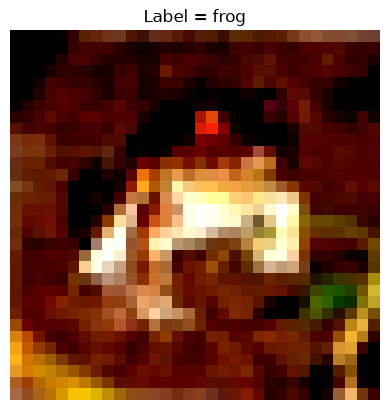

In [75]:
def visualize_tensor_data(data: torch.Tensor, label: int):
    # Data is a tensor of shape [C, W, H]  (C is the channel dimension, 3 for RGB)
    # Put channel at last
    data = data.permute(1, 2, 0)
    print(f"{data.shape=}")
    # Un-normalize
    data = data * torch.tensor(MEAN) + torch.tensor(STD)
    plt.imshow(data)
    plt.axis("off")
    plt.title(f"Label = {class_names[label]}")


visualize_tensor_data(data, class_name)

In [76]:
class_name

6

In [140]:
# set up the model and optimizer

import torch.optim as optim

model = VisionTransformer(
    n_channels=3,
    nout=10,
    img_size=32,
    patch_size=4,
    dim=128,
    attn_dim=64,
    mlp_dim=128,
    num_heads=3,
    num_layers=6,
).to(device)

criterion = nn.CrossEntropyLoss()


NUM_EPOCHS = 10
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [141]:
model

VisionTransformer(
  (patch_embed): PatchEmbed(
    (patch_embedding): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_E): Embedding(64, 128)
  (transformer): Transformer(
    (layers): ModuleList(
      (0-5): 6 x AttentionResidual(
        (attn): MultiHeadedAttention(
          (qkv_projection): Linear(in_features=128, out_features=576, bias=False)
          (W0): Linear(in_features=192, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (ffn): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=128, out_features=128, bias=True)
        )
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=128, out_features=10, bias=True)
  

In [142]:
list(model.named_modules())

[('',
  VisionTransformer(
    (patch_embed): PatchEmbed(
      (patch_embedding): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    )
    (pos_E): Embedding(64, 128)
    (transformer): Transformer(
      (layers): ModuleList(
        (0-5): 6 x AttentionResidual(
          (attn): MultiHeadedAttention(
            (qkv_projection): Linear(in_features=128, out_features=576, bias=False)
            (W0): Linear(in_features=192, out_features=128, bias=True)
          )
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (ffn): Sequential(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=128, out_features=128, bias=True)
          )
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        )
      )
    )
    (head): Sequential(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (1)

In [143]:
for parameter, w in model.named_parameters():
    print(f"{parameter=},{w.dtype}")

parameter='cls_token',torch.float32
parameter='patch_embed.patch_embedding.weight',torch.float32
parameter='patch_embed.patch_embedding.bias',torch.float32
parameter='pos_E.weight',torch.float32
parameter='transformer.layers.0.attn.qkv_projection.weight',torch.float32
parameter='transformer.layers.0.attn.W0.weight',torch.float32
parameter='transformer.layers.0.attn.W0.bias',torch.float32
parameter='transformer.layers.0.norm1.weight',torch.float32
parameter='transformer.layers.0.norm1.bias',torch.float32
parameter='transformer.layers.0.ffn.0.weight',torch.float32
parameter='transformer.layers.0.ffn.0.bias',torch.float32
parameter='transformer.layers.0.ffn.2.weight',torch.float32
parameter='transformer.layers.0.ffn.2.bias',torch.float32
parameter='transformer.layers.0.norm2.weight',torch.float32
parameter='transformer.layers.0.norm2.bias',torch.float32
parameter='transformer.layers.1.attn.qkv_projection.weight',torch.float32
parameter='transformer.layers.1.attn.W0.weight',torch.float32
p

In [144]:
img.shape

torch.Size([80, 3, 32, 32])

In [145]:
# evaluate the model


def evaluate_cifar_model(model, criterion, val_loader):
    is_train = model.training
    model.eval()
    with torch.no_grad():
        loss_meter, acc_meter = AverageMeter(), AverageMeter()
        for img, labels in val_loader:
            # move all img, labels to device (cuda)
            img = img.to(device)
            labels = labels.to(device)
            outputs, _ = model(img)
            loss_meter.update(criterion(outputs, labels).item(), len(img))
            acc = (outputs.argmax(-1) == labels).float().mean().item()
            acc_meter.update(acc, len(img))
    model.train(is_train)
    return loss_meter.calculate(), acc_meter.calculate()

In [146]:
# Time Estimate: less than 5 minutes on T4 GPU
# train the model
import tqdm

for epoch in range(NUM_EPOCHS):  #
    loss_meter = AverageMeter()
    acc_meter = AverageMeter()
    for img, labels in tqdm.tqdm(train_dataloader):
        img, labels = img.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs, _ = model(img)
        loss = criterion(outputs, labels)
        loss_meter.update(loss.item(), len(img))
        acc = (outputs.argmax(-1) == labels).float().mean().item()
        acc_meter.update(acc, len(img))
        loss.backward()
        optimizer.step()
    scheduler.step()
    print(
        f"Train Epoch: {epoch}, Loss: {loss_meter.calculate()}, Acc: {acc_meter.calculate()}"
    )
    if epoch % 10 == 0:
        val_loss, val_acc = evaluate_cifar_model(model, criterion, val_dataloader)
        print(f"Val Epoch: {epoch}, Loss: {val_loss}, Acc: {val_acc}")

val_loss, val_acc = evaluate_cifar_model(model, criterion, val_dataloader)
print(f"Val Epoch: {epoch}, Loss: {val_loss}, Acc: {val_acc}")
print("Finished Training")

  1%|          | 1/196 [00:02<07:41,  2.36s/it]



-------------------------Transformer: torch.Size([256, 65, 128])
name='Input', Variance=0.09754788875579834
name='after first attention block output', Variance=0.0035417682956904173
name='after residual 1 adding output to Z', Variance=0.10307454317808151
name='after Applying FeedForward output with residual', Variance=0.10929536074399948
Residual Block


name='Input', Variance=0.10929536074399948
name='after first attention block output', Variance=0.004055643454194069
name='after residual 1 adding output to Z', Variance=0.11226493120193481
name='after Applying FeedForward output with residual', Variance=0.1160268783569336
Residual Block


name='Input', Variance=0.1160268783569336
name='after first attention block output', Variance=0.004551802296191454
name='after residual 1 adding output to Z', Variance=0.1227574422955513
name='after Applying FeedForward output with residual', Variance=0.1317175179719925
Residual Block


name='Input', Variance=0.1317175179719925
name='after first att

  2%|▏         | 3/196 [00:02<01:57,  1.64it/s]



-------------------------Transformer: torch.Size([256, 65, 128])
name='Input', Variance=0.08754150569438934
name='after first attention block output', Variance=0.0030837852973490953
name='after residual 1 adding output to Z', Variance=0.09198642522096634
name='after Applying FeedForward output with residual', Variance=0.09809278696775436
Residual Block


name='Input', Variance=0.09809278696775436
name='after first attention block output', Variance=0.004164902959018946
name='after residual 1 adding output to Z', Variance=0.10064283758401871
name='after Applying FeedForward output with residual', Variance=0.10386636108160019
Residual Block


name='Input', Variance=0.10386636108160019
name='after first attention block output', Variance=0.004199055954813957
name='after residual 1 adding output to Z', Variance=0.1097097247838974
name='after Applying FeedForward output with residual', Variance=0.11698506027460098
Residual Block


name='Input', Variance=0.11698506027460098
name='after first

  3%|▎         | 5/196 [00:02<00:57,  3.34it/s]

...



-------------------------Transformer: torch.Size([256, 65, 128])
name='Input', Variance=0.08658165484666824
name='after first attention block output', Variance=0.02054656855762005
name='after residual 1 adding output to Z', Variance=0.1038958951830864
name='after Applying FeedForward output with residual', Variance=0.13719019293785095
Residual Block


name='Input', Variance=0.13719019293785095
name='after first attention block output', Variance=0.05860564112663269
name='after residual 1 adding output to Z', Variance=0.19808393716812134
name='after Applying FeedForward output with residual', Variance=0.24390007555484772
Residual Block


name='Input', Variance=0.24390007555484772
name='after first attention block output', Variance=0.07142118364572525
name='after residual 1 adding output to Z', Variance=0.32502618432044983
name='after Applying FeedForward output with residual', Variance=0.3725341856479645
Residual Block


name='Input', Variance=0.3725341856479645
name='after first atten

100%|██████████| 196/196 [00:32<00:00,  6.09it/s]


Train Epoch: 8, Loss: 0.9158258941459656, Acc: 0.680260000038147


  0%|          | 0/196 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=100, pipe_handle=117)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
  File "/Users/deven/Developer/Machine_Learning_Algorithms/.venv/lib/python3.14/site-packages/torch/__init__.py", line 2254, in <module>
    from torch import _VF as _VF, functional as functional  # usort: skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/deven/Developer/Machine_Learning_Algorithms/.venv/lib/python3.14/site-packages/t

KeyboardInterrupt: 

# Part 3.D

In [ ]:
for val_batch in val_dataloader:
    break

model.eval()
with torch.no_grad():
    img, labels = val_batch
    img = img.cuda()
    outputs, attns = model(img, return_attn=True)

fig, ax = plt.subplots(2, 10, figsize=(10, 2))
for i in range(10):
    flattened_attns = (
        attns.flatten(1, 2)[:, :, 0, 1:].mean(1).reshape(-1, 8, 8).cpu().numpy()
    )
    ax[0, i].imshow(inv_transform(img[i]))
    ax[1, i].imshow(flattened_attns[i])
    ax[0, i].axis(False)
    ax[1, i].axis(False)

# Problem 4: Dialogue GPT

In [ ]:
!pip install wget

In [ ]:
import os

import wget

if not os.path.exists("input.txt"):
    wget.download(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    )

In [ ]:
with open("input.txt", "r") as f:
    raw_text = f.read()
all_dialogues = raw_text.split("\n\n")

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")

## Part 4.A

In [ ]:
def tokenize(s):
    return word_tokenize(s)


class MyTokenizer:
    def __init__(self, raw_text: str):
        # raw_text     contains the text from which we will build our vocabulary

        self.start = "<START>"  # token that starts every example
        self.pad = "<PAD>"  # token used to pad examples to the same length
        self.unk = "<UNK>"  # token used if encountering a word not in our vocabulary

        vocab = np.unique(tokenize(raw_text))
        vocab = np.concatenate([np.array([self.start, self.pad, self.unk]), vocab])

        self.vocab = vocab  # array of tokens in order
        self.tok_to_id = {w: i for i, w in enumerate(vocab)}  # mapping of token to ID
        self.vocab_size = len(self.vocab)  # size of vocabulary

    def encode(self, s: str) -> torch.Tensor:
        # s           input string
        #
        # Output
        # id_tensor   a tensor of token ids, starting with the start token.t

        id_tensor = None

        # TODO: tokenize the input using word_tokenize. Return a tensor
        # of the token ids, starting with the token id for the start token.
        # ============ ANSWER START ===========

        # ============ ANSWER END =============

        return id_tensor

    def decode(self, toks: torch.Tensor) -> str:
        # toks         a list of token ids
        #
        # Output
        # decoded_str  the token ids decoded back into a string (join with a space)

        decoded_str = None

        # TODO: convert the token ids back to the actual corresponding words.
        # Join the tokens with a space and return the full string
        # ============ ANSWER START ===========

        # ============ ANSWER END =============

        return decoded_str

    def pad_examples(self, tok_list: List[torch.Tensor]) -> torch.Tensor:
        # Pads the tensors to the right with the pad token so that they are the same length.
        #
        # tok_list       a list of tensors containing token ids (maybe of different lengths)
        #
        # Output
        # padded_tokens  shape: (len(tok_list), max length within tok_list)
        return torch.nn.utils.rnn.pad_sequence(
            tok_list, batch_first=True, padding_value=self.tok_to_id[self.pad]
        )


tok = MyTokenizer(raw_text)

In [ ]:
# tokenizer test cases
input_string = "KING RICHARD III:\nSay that I did all this for love of her."
enc = tok.encode(input_string)
print(enc)
dec = tok.decode(enc)
print(dec)
assert dec == "<START> KING RICHARD III : Say that I did all this for love of her ."

# Part 4.B

In [ ]:
class DialogueDataset:
    def __init__(self, tokenizer: MyTokenizer, lines: List[str], max_N: int):
        # tokenizer    an instance of MyTokenizer
        # lines        a list of strings. each element in an example in the dataset
        # max_N        the maximum number of tokens allowed per example. More than this will be truncated
        self.lines = lines
        self.tokenizer = tokenizer
        self.max_N = max_N

    def __len__(self) -> int:
        return len(self.lines)

    def __getitem__(self, idx: int) -> torch.Tensor:
        # returns the example at int encoded by the tokenizer
        # truncates the example if it is more than max_N tokens
        return self.tokenizer.encode(self.lines[idx])[: self.max_N]


def collate_fn(examples: List[torch.Tensor]):
    # examples        a batch of tensors containing token ids (maybe of different lengths)
    # Outputs a dictionary containing
    #   input_ids     a single tensor with all of the examples padded (from the right) to the max
    #                 length within the batch. shape:(B, max length within examples)
    #   input_mask    a tensor indicating which tokens are padding and should be ignored. 0 if padding
    #                 and 1 if not. shape: (B, max length within examples)
    new_input_ids = tok.pad_examples(examples)
    attn_mask = torch.ones(new_input_ids.shape)
    attn_mask[new_input_ids == tok.tok_to_id[tok.pad]] = 0
    return {"input_ids": tok.pad_examples(examples), "input_mask": attn_mask}


ds = DialogueDataset(tok, all_dialogues, max_N=200)
training_dl = torch.utils.data.DataLoader(ds, batch_size=64, collate_fn=collate_fn)

In [ ]:
# take a look at an example of an element from the training dataloader
for batch in training_dl:
    print(batch)
    break

## Part 4.C

In [ ]:
embs = torch.ones((32, 100, 128))
B, T, _ = embs.shape
pos_ids = torch.arange(T).expand(B, -1)
print(pos_ids)
pos_E = nn.Embedding(200, 128)
print(pos_E)
pos_E(pos_ids).shape

In [ ]:
class DialogueGPT(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_N: int,
        dim: int,
        attn_dim: int,
        mlp_dim: int,
        num_heads: int,
        num_layers: int,
    ):
        # vocab_size       size of the vocabulary
        # max_N            maximum number of tokens allowed to appear in 1 example
        # dim              embedding dimension
        # attn_dim         the hidden dimension of the attention layer
        # mlp_dim          the hidden layer dimension of the FFN
        # num_heads        the number of heads in the attention layer
        # num_layers       the number of attention layers.

        super().__init__()

        # TODO: set up the token embedding and positional embeddings
        #       Hint, use nn.Embedding
        # ============ ANSWER START ============

        # ============ ANSWER END ==============

        self.transformer = Transformer(
            dim=dim,
            attn_dim=attn_dim,
            mlp_dim=mlp_dim,
            num_heads=num_heads,
            num_layers=num_layers,
        )

        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, vocab_size))

    def forward(
        self, input_ids: torch.Tensor, return_attn=False
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        # input_ids     a batch of input ids (right padded). shape: (B x T)
        # return_attn   whether to return the attention weights
        #
        # Output
        # out           the logit vector (B x T x V)
        # alphas        the attention weights if return_attn is True. Otherwise None shape: (B, num_layers, num_heads, T, T)

        embs = None

        # TODO: retrieve the token embeddings for the input_ids.
        #       Add to the token embeddings the positional embeddings.
        #       Store the combined embedding in embs
        # ============ ANSWER START ============

        # ============ ANSWER END ============

        causal_attn_mask = None

        # TODO: Create the causal attention mask, which should be of size (B, T, T)
        #       Remember that the causal attention mask is lower triangular (all tokens only
        #       depend on themselves and the tokens before them).
        # .      Store the mask in causal_attn_mask
        # Hint: check out torch.tril
        # ============ ANSWER START ============

        # ============ ANSWER END ==============

        x, alphas = self.transformer(
            embs, attn_mask=causal_attn_mask, return_attn=return_attn
        )
        out = self.head(x)
        return out, alphas

    def generate(self, input_ids, num_tokens):
        # you can assume batch size 1
        with torch.no_grad():
            for i in range(num_tokens):
                out, _ = self.forward(input_ids)
                new_token = torch.argmax(out[:, [-1]], -1)
                input_ids = torch.cat([input_ids, new_token], dim=1)
        return input_ids

## Part 4.D

In [ ]:
class DialogueLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.criterion = nn.CrossEntropyLoss(reduction="none")

    def forward(
        self, logits: torch.Tensor, input_ids: torch.Tensor, inp_mask: torch.Tensor
    ):
        # logits      the logits produced by DialogueGPT. shape: (B x T x V)
        # input_ids   the token ids. shape: (B x T)
        # inp_mask    a 0/1 mask of which tokens are padding tokens and should be ignored. shape: (B x T)

        # TODO: Implement the language model loss. For logits[i], we want to supervise the i+1 token_id
        # with the cross entropy loss. We thus will not supervise the start token (input_ids[0]) or use
        # the last logit vector (logits[-1]). Return the average of the losses for each token in the batch,
        # making sure to ignore tokens corresponding to the padding (use inp_mask).

        # ============ ANSWER START ============

        # ============ ANSWER END ==============
        return loss

## Part 4.F

In [ ]:
import torch.optim as optim

model = DialogueGPT(
    vocab_size=tok.vocab_size,
    max_N=200,
    dim=128,
    attn_dim=64,
    mlp_dim=128,
    num_heads=3,
    num_layers=6,
).cuda()
criterion = DialogueLoss()

NUM_EPOCHS = 80


optimizer = optim.AdamW(
    model.parameters(), lr=0.0001, weight_decay=0
)  # implement in homework
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
# Time estimate: around 30 minutes on T4 GPU
# Training
import tqdm

for epoch in range(NUM_EPOCHS):  # loop over the dataset multiple times
    loss_meter = AverageMeter()
    for inp_dict in tqdm.tqdm(training_dl):
        # get the inputs; data is a list of [inputs, labels]
        inp_ids, inp_mask = inp_dict["input_ids"], inp_dict["input_mask"]
        inp_ids = inp_ids.cuda()
        inp_mask = inp_mask.cuda()
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs, _ = model(input_ids=inp_ids)
        loss = criterion(outputs, inp_ids, inp_mask)
        loss_meter.update(loss.item(), len(inp_dict["input_ids"]))
        loss.backward()
        optimizer.step()
    scheduler.step()

    # print example
    inp = tok.encode("").unsqueeze(0).cuda()
    print(tok.decode(model.generate(inp, 10)[0].cpu()))

    print(
        f"Train Epoch: {epoch}, Loss: {loss_meter.calculate():0.4f}, LR: {scheduler.get_last_lr()[0]}"
    )

## Part 4.G

In [ ]:
inp = tok.encode("").unsqueeze(0).cuda()
print(tok.decode(model.generate(inp, 50)[0].cpu()))